# 🔍 Notebook-07: RAG – Retrieval-Augmented Generation
**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**

---

| | |
|---|---|
| **Session** | S 2.4 – Retrieval-Augmented Generation |
| **Dauer** | ~35 Minuten |
| **Format** | Vollständige RAG-Pipeline – konzeptionell + praktisch |
| **Ziel** | Verstehen warum RAG existiert, wie es funktioniert – und es live auf einer Ermittlungsakte ausführen |

---

### 🗺️ Was wir heute durchlaufen

```
KONZEPT          DOKUMENT         INDEX            RETRIEVAL        ANTWORT
   |                |                |                  |               |
Warum reicht     Ermittlungs-     Text in          Frage stellen,    LLM antwortet
ein LLM allein   akte laden       Chunks teilen,   relevante         mit Quellenangabe
nicht? Was ist   und erkunden     Embeddings        Chunks finden     statt zu
RAG?             (Teil 1)         berechnen,                         halluzinieren
                                  Index bauen
                                  (Teile 2-3)       (Teil 4)          (Teil 5)
```

---

> ### 📌 Keine Programmiererfahrung nötig
>
> Jede Code-Zelle ist vollständig erklärt — was sie tut, warum sie es tut,
> und was das Ergebnis bedeutet. Lesen, ausführen, beobachten.
>
> **Alles ausführen:** Menü → *Runtime → Run all*

---

> ### 🔗 Verbindung zu S2.3 (Fine-tuning)
>
> In S2.3 haben wir gesehen wie Fine-tuning dem Modell einen **Stil** beibringt.
> RAG löst ein anderes Problem: Es gibt dem Modell **Zugang zu konkreten Fakten**
> aus unseren eigenen Dokumenten — ohne Training, ohne Cloud, DSGVO-konform.
>
> **Fine-tuning:** Das Modell schreibt wie die Polizei BW ✅  
> **RAG:** Das Modell kennt unsere aktuellen Dokumente ✅  
> **Kombination:** Optimaler lokaler Assistent (das Ziel) ✅


---

## 🧠 Teil 0 – Warum brauchen wir RAG? Das Grundproblem

### Das Problem mit LLMs und Fakten

Ein LLM wie Llama 3.1 8B wurde mit Texten aus dem Internet trainiert —
Stand: irgendwann in der Vergangenheit. Es kennt:

- ✅ Allgemeines Wissen: Geschichte, Recht, Sprache, Konzepte
- ✅ Wie man Texte schreibt, zusammenfasst, übersetzt
- ❌ **Ihre Ermittlungsakte von heute**
- ❌ **Aktuelle interne Dienstvorschriften**
- ❌ **Den Inhalt eines bestimmten Dokuments, das Sie haben**

Wenn Sie ein LLM nach dem Inhalt Ihrer Akte fragen, macht es das Einzige, was es kann:
Es **erfindet eine plausibel klingende Antwort** — auch wenn sie falsch ist.
Das nennt man **Halluzination**.

---

### Die RAG-Lösung: Nachschlagen statt Erinnern

**RAG** (Retrieval-Augmented Generation) ist wie ein Assistent,
der **zuerst im Dokument nachschaut** und dann antwortet:

```
Ohne RAG:   Frage  =>  LLM  =>  Antwort (erfunden oder veraltet)

Mit RAG:    Frage  =>  Suche in Dokumenten  =>  relevante Textstellen
                   =>  LLM + Textstellen    =>  Antwort mit Quellenangabe
```

Der entscheidende Unterschied: Das LLM bekommt die relevanten Textstellen
**als Kontext mitgeliefert** — es muss nichts mehr erfinden.

---

### Die fünf Schritte einer RAG-Pipeline

```
Schritt 1:  DOKUMENT LADEN      Die Akte, Dienstvorschrift, Gesetzestext einlesen
Schritt 2:  CHUNKING            Text in kleine, sinnvolle Abschnitte aufteilen
Schritt 3:  EMBEDDINGS + INDEX  Jeden Abschnitt als Zahlenvektor speichern
Schritt 4:  RETRIEVAL           Aehnliche Abschnitte zu einer Frage finden
Schritt 5:  ANTWORT             LLM generiert Antwort aus gefundenen Abschnitten
```

Wir bauen diese Pipeline heute Schritt für Schritt auf.

---

### 🛠️ Drei Wege zu RAG — von einfach bis vollständig

Bevor wir in den Code einsteigen: Es gibt verschiedene Wege, RAG in der Praxis zu nutzen.

| Weg | Werkzeug | Aufwand | Für wen? |
|-----|---------|---------|----------|
| **Kein Setup** | **NotebooklLM, FindusGPT, F13** | Sekunden | Alle |
| **Lokal einfach** | **AnythingLLM, OpenWebUI** | 15 Min. | IT-affine Nutzer |
| **Vollständig lokal** | **ChromaDB + Ollama** (Code) | Stunden | Entwickler/dieses Notebook |

#### NotebooklLM, FindusGPT, F13 u.a. — RAG ohne Technik
Die Anwendungen besitzen eine eingebaute RAG-Funktion: Dokument hochladen → befragen.
Kein Code, keine Installation.

#### AnythingLLM, OpenWebUI u.a. — lokale Desktop-RAG
Die Anwendungen können lokal instaliert werden und ermöglichen ein RAG über eigene Dokumente: PDF, Word, Text hochladen, lokal fragen — Ollama als Backend.

#### Dieses Notebook — vollständiges Verständnis
Wir bauen RAG vollständig selbst — damit Sie verstehen was "unter der Haube" passiert.


---

### 🚨 F13 – Die dienstinterne KI-Assistenz der Polizei Baden-Württemberg

Neben Anwendungen wie NotebookLM, FindusGPT und AnythingLLM gibt es für die Polizei BW einen dienstinternen Weg: **F13**.

---

#### Was ist F13?

F13 ist eine **on-premise KI-Plattform**, die:
- vollständig auf eigener Infrastruktur der Landesverwaltung betrieben wird
- **RAG über eigene Verwaltungsdokumente** anbietet (Wissensdatenbank-Funktion)
- modell-agnostisch ist — aktuell laufen openSource Modelle wie Llama 3.3, gpt-oss u.a.
- seit Juli 2025 als **Open-Source-Software** auf openCode.de verfügbar ist (MPL-2.0)

---

#### Relevanz für die Polizei BW — Projekt KIRKE

Die Polizei Baden-Württemberg betreibt F13 unter dem Projektnamen
**KIRKE**, angesiedelt im Präsidium Technik, Logistik, Service der Polizei BW.

---

> 💡 **Für den Seminarkontext:**
> F13 ist der institutionelle Weg, wie RAG fuer die Polizei BW langfristig aussieht.
> Dieses Notebook zeigt, was technisch hinter allen drei Systemen steckt —
> wer das versteht, nutzt F13 besser und erkennt seine Grenzen.

**Links:**
- openCode.de: https://opencode.de/de/software/f-13-ki-assistenz-5250
- Quellcode: https://gitlab.opencode.de/f13
- F13-OS Webseite: https://f13-os.de


---

## 📐 Exkurs: Dokument-Ontologie — Struktur verstehen, bevor man sucht

Bevor wir ein Dokument in ein RAG-System laden, lohnt es sich zu fragen:
**Was für ein Dokument ist das eigentlich? Wie ist es aufgebaut?**

Das ist keine philosophische Frage — es hat direkte praktische Konsequenzen
dafür, wie wir es in Chunks aufteilen und was wir suchen können.

---

### Was ist eine Dokument-Ontologie?

Eine **Ontologie** beschreibt die Struktur, Typen und Beziehungen in einer Dokumentensammlung.
Für RAG bedeutet das:

```
Dokument-Typ           Struktur              Suchstrategie
---------------------------------------------------------
Ermittlungsakte     => Abschnitte (Sachverhalt,      semantische Abschnitte
                        Finanzen, Verdaechtige...)
Gesetzestext        => Paragraphen, Absaetze          paragraph-basiert
Dienstvorschrift    => Kapitel, Unterkapitel           hierarchisch
Chat-Export         => Nachrichten, Zeitstempel        chronologisch
Zeugenbefragung     => Frage/Antwort-Paare             Q&A-Paare
```

---

### Warum spielt das für RAG eine Rolle?

**Problem:** Ein LLM "sieht" nur Text — es weiß nicht, dass Paragraph 4 Absatz 2
eine andere Bedeutung hat als Paragraph 4 Absatz 3. Wir müssen ihm helfen.

**Beispiel Ermittlungsakte:**
- Wenn wir nach einer IBAN fragen => wir brauchen den **Finanztransaktions-Abschnitt**
- Wenn wir nach dem Verdächtigen fragen => wir brauchen den **Personen-Abschnitt**
- Wenn wir nach dem Tatbestand fragen => wir brauchen den **Rechtlichen Abschnitt**

Ein gutes RAG-System kennt diese Struktur und nutzt sie.

---

### Drei Chunking-Strategien im Vergleich

```
1. NAIV (feste Groesse):
   "... S 263 StGB | Betrug Taeusch | ung durch De | epfake als a | rglisti ..."
   => Schneidet mitten durch wichtige Informationen
   => Gut: einfach, vorhersehbar

2. SEMANTISCH (an Strukturgrenzen):
   "--- ABSCHNITT 5: RECHTLICHE EINORDNUNG ---
    Paragraf 263 StGB, Paragraf 269 StGB..."
   => Respektiert die Dokument-Ontologie
   => Besser fuer strukturierte Dokumente

3. HIERARCHISCH (Typ + Inhalt):
   Metadaten: {typ: "Rechtlich", S: "263", kontext: "Betrug"}
   => Ermoeglicht gezieltes Filtern vor dem Retrieval
   => Beste Qualitaet, hoechster Aufwand, Vorstrukturierung der Daten notwendig!
```

**In diesem Notebook** verwenden wir Strategie 1 und 2 und vergleichen sie.


---

## ⚙️ Setup – Werkzeuge laden

Diese Zelle bereitet alles vor. Kurz ausführen — dauert wenige Sekunden.

> 💡 **Was die Bibliotheken machen:**
> - `numpy` – Mathematik mit Zahlen-Listen (brauchen wir für Vektoren)
> - `matplotlib` – Grafiken und Diagramme
> - `re` – Texte nach Mustern durchsuchen (z.B. "--- ABSCHNITT")
> - `chromadb` – Vektordatenbank (wo wir die Embeddings speichern)
> - `sentence_transformers` – Texte in Zahlen-Vektoren umwandeln
>
> Die Zelle prüft außerdem, ob Ollama läuft und welche Modelle verfügbar sind.


In [30]:
# == Bibliotheken laden ==
# Jede Zeile laedt ein Werkzeug

import numpy as np               # Mathematik: Vektoren, Berechnungen
import matplotlib.pyplot as plt  # Grafiken: Diagramme, Visualisierungen
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')  # Unwichtige Warnmeldungen unterdruecken
import re, textwrap, os, importlib  # Textwerkzeuge

# == Farbpalette (Polizei BW Corporate Design) ==
# C ist ein Woerterbuch: C['navy'] gibt den Hex-Farbcode fuer Dunkelblau zurueck
C = {
    'navy':   '#001E46',  # Dunkelblau (Hintergrund)
    'blue1':  '#0D3761',  # Mittelblau
    'blue2':  '#1A4E8A',  # Hellblau
    'ice':    '#4FC3F7',  # Eisblau
    'orange': '#ED7D31',  # Orange (Highlights)
    'green':  '#52B788',  # Gruen (Erfolg, RAG)
    'teal':   '#00B4D8',  # Tuerki (Embeddings)
    'lgray':  '#B0C4DE',  # Hellgrau (Beschriftungen)
    'white':  '#FFFFFF',  # Weiss
    'gold':   '#FFC300',  # Gold (Warnungen)
    'red':    '#E74C3C',  # Rot (Fehler, Halluzination)
}

# Grafik-Stil anpassen
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': C['navy'],
    'axes.facecolor':   C['blue1'],
    'axes.edgecolor':   C['lgray'],
    'xtick.color':      C['lgray'],
    'ytick.color':      C['lgray'],
    'text.color':       C['white'],
    'grid.color':       '#1A4E8A',
    'grid.alpha':       0.4,
    'font.size':        11,
})

# == Verfuegbarkeits-Check ==
# Wir pruefen welche optionalen Bibliotheken installiert sind
print('UMGEBUNGS-CHECK -- Welche Werkzeuge sind verfuegbar?')
print('=' * 55)

HAVE = {}  # Leeres Woerterbuch, wird befuellt
for pkg in ['chromadb', 'sentence_transformers', 'openai', 'sklearn']:
    # importlib.util.find_spec() prueft ob ein Paket installiert ist
    HAVE[pkg] = importlib.util.find_spec(pkg) is not None
    status = '✅ installiert' if HAVE[pkg] else '❌  pip install ' + pkg.replace('_', '-')
    print(f'  {pkg:<30} {status}')

# == Ollama pruefen ==
# Ollama ist der lokale LLM-Server -- wir fragen ihn ueber HTTP an Port 11434
import urllib.request, json as _json

print()
print('OLLAMA (lokaler KI-Server):')
try:
    with urllib.request.urlopen('http://localhost:11434/api/tags', timeout=3) as r:
        models = [m['name'] for m in _json.loads(r.read())['models']]
    print(f'  ✅ Ollama laeuft -- verfuegbare Modelle: {models}')
    HAVE['ollama'] = True
    # Fuer RAG: Basis-Modell bevorzugen (folgt Instruktionen besser als Fine-tuned)
    # polizei-bw hat Schreibstil gelernt, aber kein Instruction-Following fuer RAG
    _rag_model = next(
        (m for m in models if 'llama3.1' in m and 'polizei' not in m),
        next((m for m in models if 'llama3.1' in m), models[0] if models else 'llama3.1:8b')
    )
    OLLAMA_MODEL = _rag_model
    print(f'  Verwende Modell: {OLLAMA_MODEL}')
    if 'polizei' in OLLAMA_MODEL:
        print('  ⚠️  Fine-tuned Modell erkannt — fuer RAG empfohlen: llama3.1:8b')
except Exception as e:
    print(f'  ℹ️  Ollama nicht erreichbar (Fallback: regelbasierte Antworten)')
    print(f'     Starten mit: ollama serve')
    HAVE['ollama'] = False
    OLLAMA_MODEL = None

OLLAMA_BASE = 'http://localhost:11434/v1'

print()
if HAVE.get('chromadb') and HAVE.get('sentence_transformers') and HAVE.get('ollama'):
    modus = '🟢 VOLLSTAENDIG -- ChromaDB + sentence-transformers + Ollama'
elif HAVE.get('chromadb') and HAVE.get('sentence_transformers'):
    modus = '🟡 TEILWEISE -- ChromaDB + sentence-transformers (ohne Ollama)'
else:
    modus = '🔵 FALLBACK -- TF-IDF + regelbasierte Antworten (kein Download)'
print(f'Modus: {modus}')
print('Setup OK -- Notebook bereit ✅')


UMGEBUNGS-CHECK -- Welche Werkzeuge sind verfuegbar?
  chromadb                       ✅ installiert
  sentence_transformers          ✅ installiert
  openai                         ✅ installiert
  sklearn                        ✅ installiert

OLLAMA (lokaler KI-Server):
  ✅ Ollama laeuft -- verfuegbare Modelle: ['polizei-bw:latest', 'llama3:70b', 'deepseek-r1:8b', 'gemma3:27b', 'qwen3-vl:30b', 'gpt-oss:120b', 'gpt-oss:20b', 'llama3:8b', 'mistral-small3.1:24b', 'deepseek-coder:33b', 'huihui_ai/deepseek-r1-abliterated:8b']
  Verwende Modell: polizei-bw:latest
  ⚠️  Fine-tuned Modell erkannt — fuer RAG empfohlen: llama3.1:8b

Modus: 🟢 VOLLSTAENDIG -- ChromaDB + sentence-transformers + Ollama
Setup OK -- Notebook bereit ✅


---

## 📁 Teil 1 – Dokument laden und erkunden

### Was ist ein RAG-Dokument?

RAG funktioniert mit **jedem Text-Dokument** — Ermittlungsakten, Dienstvorschriften,
Gesetzestexte, Urteile, Handbucher, Chat-Exports, Berichte.

**In der Praxis** laden Sie:
- 📄 PDF-Dateien → werden in Text umgewandelt (PyMuPDF, pdfminer)
- 📝 Word-Dokumente → python-docx
- 🌐 Webseiten → requests + BeautifulSoup
- 📊 Tabellen → pandas

**In diesem Notebook** arbeiten wir mit einer **synthetischen Ermittlungsakte**.

### Struktur unserer Akte (Dokument-Ontologie)

```
1. SACHVERHALTSDARSTELLUNG   Was ist passiert?
2. FINANZTRANSAKTIONEN       Wohin floss das Geld?
3. TATVERDA'CHTIGE           Wer ist verdaechtig?
4. DIGITALE SPURENSICHERUNG  Welche digitalen Beweise gibt es?
5. RECHTLICHE EINORDNUNG     Welche Paragraphen greifen?
6. MASSNAHMEN                Was wurde angeordnet?
```

Diese Struktur hilft uns beim Chunking — wir können die Abschnitte als
natürliche Chunk-Grenzen nutzen.


In [31]:
# == Ermittlungsakte (synthetisch) ==
# Triple-Anfuehrungszeichen erlauben mehrzeiligen Text in Python.
# Alles dazwischen ist ein langer Absatz.

AKTE = """
=== ERMITTLUNGSAKTE AZ 2026-KK-00471 ===
Ermittlungsbehoerde: LKA Baden-Wuerttemberg, Abt. Cybercrime
Aktenzeichen: 2026-KK-00471
Ermittlungsbeginn: 14.01.2026
Bearbeiter: KHK Hoffmann
Betreff: Verdacht auf gewerbsmaessigen Betrug mittels gefaelschter Identitaeten (Deepfake)

--- ABSCHNITT 1: SACHVERHALTSDARSTELLUNG ---
Am 09.01.2026 erstattete die Firma DataTrust GmbH, Stuttgart, Strafanzeige gegen unbekannt.
Der Anzeigeerstatter, Herr Thomas Bremer (GF), schilderte folgenden Sachverhalt:
Ein unbekannter Taetersoll sich per Video-Call als Prokurist Dr. Ewald Fink ausgegeben und
eine dringende Ueberweisung von 93.400 EUR angeordnet haben.
Das Video wurde als KI-generierter Deepfake eingestuft (Gutachten Anlage 3).
Die Ueberweisung erfolgte auf IBAN DE89 3704 0044 0532 0130 00 (Empfaenger: Baltic Trade LLC).

--- ABSCHNITT 2: FINANZTRANSAKTIONEN ---
Transaktion 1: 09.01.2026, 14:32 Uhr, 93.400 EUR
  Auftraggeber: DataTrust GmbH, DE44 2004 1155 0667 0013 00
  Empfaenger: Baltic Trade LLC, IBAN DE89 3704 0044 0532 0130 00
  Verwendungszweck: Projektabrechnung Q4
  Status: Ausfuehrung erfolgt, Rueckbuchung beantragt (abgelehnt)
Transaktion 2: 10.01.2026, 09:15 Uhr, 28.750 EUR
  Auftraggeber: DataTrust GmbH, DE44 2004 1155 0667 0013 00
  Empfaenger: Eastern Consulting SARL, LU28 0019 4006 4475 0000
  Verwendungszweck: Beratungsleistungen
  Status: Ausfuehrung erfolgt
Gesamtschaden: 122.150 EUR
Zielkonten: Bulgarien und Luxemburg (Ueberweisungen an Drittlaender eingeleitet)

--- ABSCHNITT 3: TATVERDAECHTIGE UND KONTAKTPERSONEN ---
TV1: Unbekannt (Nutzer des Deepfake-Videos)
  Vermutlich organisierte Kriminalitaet mit technischer Infrastruktur
TV2: Maksym Bondarenko, geb. 1988, letzter bek. Aufenthalt Kiew/Ukraine
  Verbindung zu Baltic Trade LLC (als Director eingetragen, Quelle: Registerauszug Anlage 7)
  Telefonnummer: +380 44 123 4567 (Prepaid, nicht zuordenbar)
  E-Mail: m.bondarenko@baltictrade-eu.com
Zeuge: Karin Riedel, Buchhaltung DataTrust GmbH
  Hat die Ueberweisung auf Anweisung ausgefuehrt, konnte Deepfake nicht als solchen erkennen.

--- ABSCHNITT 4: DIGITALE SPURENSICHERUNG ---
Sichergestellte Beweise:
  - Deepfake-Video (MP4, 2:34 Min, Hash SHA-256: a3f9...cc12)
  - E-Mail-Header der Tatmails (Anlage 4): IP 185.220.101.47 (Tor-Exit-Node Niederlande)
  - Kontozugangsdaten aus kompromittiertem E-Mail-Postfach (Anlage 5)
  - Forensischer Bericht Deepfake-Analyse (Anlage 3): Wahrscheinlichkeit KI-generiert: 97,4%
Digitale Kommunikation:
  - 7 E-Mails zwischen Taetern und Opfer (Anlage 4)
  - WhatsApp-Nachrichten von Bondarenkos letztem Mobilgeraet (Anlage 8): geloescht, wiederhergestellt

--- ABSCHNITT 5: RECHTLICHE EINORDNUNG ---
Tatbestaende:
  - Paragraf 263 StGB (Betrug): Taeuschen durch Deepfake als arglistige Taeuschung
  - Paragraf 269 StGB (Faelschung beweiserheblicher Daten): Deepfake als gefaelschte Daten
  - Paragraf 263a StGB (Computerbetrug): unbefugter Zugriff auf E-Mail-Konto
Zustaendigkeit: Staatsanwaltschaft Stuttgart, Ref. 4117
EU-Rechtshilfe: Antrag an Luxemburg und Ukraine in Vorbereitung

--- ABSCHNITT 6: MASSNAHMEN UND NAECHSTE SCHRITTE ---
Angeordnete Massnahmen:
  - Telefonueberwachung Bondarenko (Beschluss AG Stuttgart vom 20.01.2026)
  - Internationale Kontensperre beantragt (Europaeische Ermittlungsanordnung)
  - IP-Auskunft bei niederlaendischer Behoerde (Ergebnis ausstehend)
Naechste Schritte:
  - Vernehmung weiterer Zeugen bei DataTrust GmbH (geplant 28.01.2026)
  - Ergebnis der digitalen Forensik Deepfake-Labor (erwartet 15.02.2026)
  - Koordinierung mit Interpol (NC Deutschland informiert)

Stand: 22.01.2026 | KHK Hoffmann
"""

# == Akte analysieren ==
# len() gibt die Laenge eines Textes (Anzahl Zeichen) oder einer Liste zurueck
# .split() teilt einen Text an Leerzeichen auf => ergibt eine Liste von Woertern
zeichen = len(AKTE)
woerter = len(AKTE.split())

# Abschnitte finden: re.findall sucht alle Textstellen die dem Muster entsprechen
abschnitte = re.findall(r'ABSCHNITT \d+: [A-Z ]+', AKTE)

print('ERMITTLUNGSAKTE GELADEN')
print('=' * 50)
print(f'  Gesamtlaenge:   {zeichen:,} Zeichen')
print(f'  Wortanzahl:    {woerter:,} Woerter')
print(f'  Abschnitte:    {len(abschnitte)}')
print()
print('STRUKTUR DER AKTE (Dokument-Ontologie):')
for i, abschnitt in enumerate(abschnitte, 1):
    print(f'  {i}. {abschnitt.strip()}')
print()
print('ERSTE 300 ZEICHEN DER AKTE:')
print(textwrap.fill(AKTE[:300].strip(), width=65))


ERMITTLUNGSAKTE GELADEN
  Gesamtlaenge:   3,627 Zeichen
  Wortanzahl:    422 Woerter
  Abschnitte:    6

STRUKTUR DER AKTE (Dokument-Ontologie):
  1. ABSCHNITT 1: SACHVERHALTSDARSTELLUNG
  2. ABSCHNITT 2: FINANZTRANSAKTIONEN
  3. ABSCHNITT 3: TATVERDAECHTIGE UND KONTAKTPERSONEN
  4. ABSCHNITT 4: DIGITALE SPURENSICHERUNG
  5. ABSCHNITT 5: RECHTLICHE EINORDNUNG
  6. ABSCHNITT 6: MASSNAHMEN UND NAECHSTE SCHRITTE

ERSTE 300 ZEICHEN DER AKTE:
=== ERMITTLUNGSAKTE AZ 2026-KK-00471 === Ermittlungsbehoerde: LKA
Baden-Wuerttemberg, Abt. Cybercrime Aktenzeichen: 2026-KK-00471
Ermittlungsbeginn: 14.01.2026 Bearbeiter: KHK Hoffmann Betreff:
Verdacht auf gewerbsmaessigen Betrug mittels gefaelschter
Identitaeten (Deepfake)  --- ABSCHNITT 1: SACHV


---

## ✂️ Teil 2 – Chunking: Text sinnvoll aufteilen

### Warum koennen wir nicht einfach die ganze Akte ins LLM schicken?

**Kurze Antwort:** LLMs haben ein begrenztes Kontextfenster.

**Laengere Antwort:**
- Llama 3.1 8B: maximal 8.000 Token (6.000 Woerter) auf einmal
- Unsere Akte: ~700 Woerter => passt in diesem Fall noch rein
- Aber: 100-seitige Dienstvorschrift, 500 Seiten Akte => passt nicht mehr
- Ausserdem: Je mehr Text im Kontext, desto schlechter die Antwortqualitaet

**RAG loest das** indem es nur die **relevantesten Abschnitte** ins LLM schickt.

**LLMs** haben heute sehr große Kontextfenster (bis 128K+ Tokens, teilweise 200k+ bspw. Claude). Theoretisch kann man ganze Dokumente oder Akten verarbeiten.

128K Tokens ≈ 80.000 – 100.000 Wörter

In der Praxis führt viel Kontext jedoch nicht automatisch zu besseren Ergebnissen:
- Informationen in der Mitte werden schlechter berücksichtigt („Lost in the Middle“)
- Relevante Inhalte gehen im Rauschen unter
- Antworten werden ungenauer

Deshalb wird Text in kleinere Abschnitte (Chunks) aufgeteilt.
RAG sorgt dafür, dass nur die relevantesten Abschnitte an das Modell übergeben werden.

---

### Was ist ein Chunk?

Ein **Chunk** (deutsch: Brocken) ist ein kleiner Textausschnitt.
Wir teilen die ganze Akte in viele Chunks auf — jeder Chunk ist ein eigenstaendiger
Abschnitt, der separat durchsucht und gefunden werden kann.

```
Ganze Akte (700 Woerter)
    => aufteilen
Chunk 1: Sachverhaltsdarstellung (~80 Woerter)
Chunk 2: Finanztransaktionen (~90 Woerter)
Chunk 3: Tatverda'chtige (~60 Woerter)
...
```

---

### Zwei Chunking-Strategien

**Strategie A: Feste Groesse (Sliding Window)**
- Wir nehmen immer eine bestimmte Anzahl Woerter (z.B. 80)
- Ueberlappung (Overlap): Die letzten 15 Woerter eines Chunks sind auch
  die ersten 15 des naechsten -- damit kein Kontext verloren geht

**Strategie B: Semantisch (an Strukturgrenzen)**
- Wir teilen an natuerlichen Grenzen des Dokuments
- In unserer Akte: an den `--- ABSCHNITT X: ...` Trennlinien
- Respektiert die Dokument-Ontologie
- Chunk 1 = genau Abschnitt 1 (Sachverhalt), Chunk 2 = Abschnitt 2 (Finanzen), usw.

**Welche Strategie ist besser?**
Das haengt vom Dokument ab -- wir vergleichen beide.


In [32]:
# == Chunking-Funktionen ==
# Eine Funktion (def) ist ein wiederverwendbarer Code-Block.
# Sie nimmt Parameter entgegen und gibt etwas zurueck (return).

def chunk_by_size(text, chunk_size=80, overlap=15):
    """
    Strategie A: Feste Wortanzahl mit Ueberlappung (Sliding Window)

    text:       der gesamte Text
    chunk_size: Woerter pro Chunk (Standard: 80 Woerter ca. 100 Token)
    overlap:    Woerter die der naechste Chunk mit dem vorherigen teilt
    """
    words = text.split()  # .split() teilt Text in eine Wort-Liste
    chunks = []            # Leere Liste fuer unsere Chunks
    i = 0                  # Startposition

    while i < len(words):  # Solange noch Woerter uebrig sind:
        # words[i:i+chunk_size] nimmt Woerter von Position i bis i+chunk_size
        chunk_words = words[i:i + chunk_size]
        # ' '.join(...) verbindet die Woerter wieder zu einem Text
        chunks.append(' '.join(chunk_words))
        # Naechste Position: chunk_size minus overlap (damit Ueberlappung entsteht)
        i += chunk_size - overlap

    return chunks


def chunk_by_section(text):
    """
    Strategie B: An semantischen Abschnittsgrenzen (--- ABSCHNITT X: ---)

    re.split() teilt den Text immer dann, wenn das Muster '---' + Grossbuchstaben vorkommt.
    Diese Strategie nutzt die Struktur unserer Akte (die Dokument-Ontologie).
    """
    # r'---\s*[A-Z]+\s+\d+:' bedeutet:
    #   ---  = Trennlinie
    #   \s*  = beliebig viele Leerzeichen
    #   [A-Z]+ = ein oder mehr Grossbuchstaben
    #   \s+  = ein oder mehr Leerzeichen
    #   \d+: = eine oder mehr Ziffern gefolgt von Doppelpunkt
    sections = re.split(r'---\s*[A-Z\u00c4\u00d6\u00dc]+\s+\d+:', text)
    chunks = []

    for section in sections:
        section = section.strip()  # Leerzeichen am Anfang/Ende entfernen
        if len(section) > 50:      # Nur Abschnitte mit mehr als 50 Zeichen behalten
            chunks.append(section)

    return chunks


# == Beide Strategien auf unsere Akte anwenden ==
chunks_fixed    = chunk_by_size(AKTE, chunk_size=80, overlap=15)
chunks_semantic = chunk_by_section(AKTE)

print('CHUNKING-ERGEBNIS')
print('=' * 55)
print(f'  Strategie A (Feste Groesse, 80 Woerter + 15 Overlap):')
print(f'    => {len(chunks_fixed)} Chunks')
print(f'    => Durchschnittlich {np.mean([len(c.split()) for c in chunks_fixed]):.0f} Woerter/Chunk')
print()
print(f'  Strategie B (Semantisch, an Abschnittsgrenzen):')
print(f'    => {len(chunks_semantic)} Chunks')
print(f'    => Durchschnittlich {np.mean([len(c.split()) for c in chunks_semantic]):.0f} Woerter/Chunk')
print()
print('BEISPIEL -- Chunk 2 (Strategie B -- Finanztransaktionen):')
print('-' * 55)
bsp = chunks_semantic[2] if len(chunks_semantic) > 2 else chunks_semantic[-1]
print(textwrap.fill(bsp[:400], 65))

# == Metadaten hinzufuegen ==
# Jeder Chunk bekommt Metadaten: Quelldokument, Position, Wortanzahl
# Das hilft spaeter bei der Quellenangabe
def add_metadata(chunks, doc_name='Akte_2026-KK-00471'):
    return [
        {
            'text':     chunk,
            'source':   doc_name,
            'chunk_id': i,
            'n_words':  len(chunk.split())
        }
        for i, chunk in enumerate(chunks)  # enumerate gibt (Index, Element)
    ]

docs_semantic = add_metadata(chunks_semantic)
docs_fixed    = add_metadata(chunks_fixed)

print()
print(f'Dokumentsammlung (semantisch): {len(docs_semantic)} Chunks mit Metadaten')


CHUNKING-ERGEBNIS
  Strategie A (Feste Groesse, 80 Woerter + 15 Overlap):
    => 7 Chunks
    => Durchschnittlich 73 Woerter/Chunk

  Strategie B (Semantisch, an Abschnittsgrenzen):
    => 7 Chunks
    => Durchschnittlich 58 Woerter/Chunk

BEISPIEL -- Chunk 2 (Strategie B -- Finanztransaktionen):
-------------------------------------------------------
FINANZTRANSAKTIONEN --- Transaktion 1: 09.01.2026, 14:32 Uhr,
93.400 EUR   Auftraggeber: DataTrust GmbH, DE44 2004 1155 0667
0013 00   Empfaenger: Baltic Trade LLC, IBAN DE89 3704 0044 0532
0130 00   Verwendungszweck: Projektabrechnung Q4   Status:
Ausfuehrung erfolgt, Rueckbuchung beantragt (abgelehnt)
Transaktion 2: 10.01.2026, 09:15 Uhr, 28.750 EUR   Auftraggeber:
DataTrust GmbH, DE44 2004 1155

Dokumentsammlung (semantisch): 7 Chunks mit Metadaten


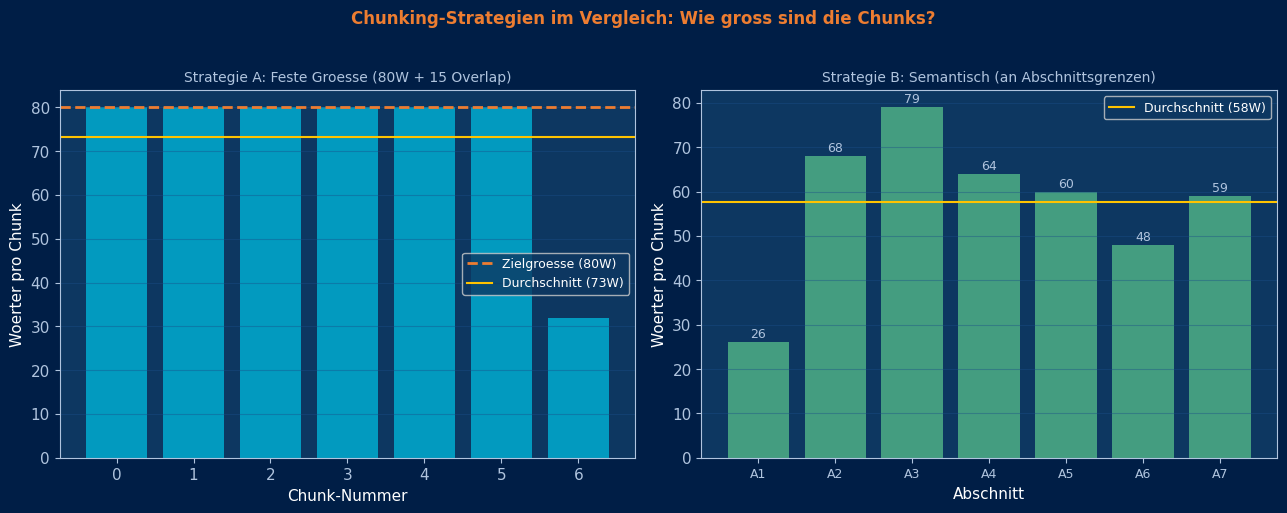


Was wir sehen:
  Strategie A: 7 gleichmaessige Chunks (~73 Woerter)
  Strategie B: 7 Abschnitt-Chunks (variabel 26-79 Woerter)

Fuer unsere strukturierte Akte: Strategie B ist besser --
jeder Chunk entspricht genau einem inhaltlichen Abschnitt.


In [33]:
# Chunk-Laengenverteilung visualisieren
# Zeigt: Wie gleichmaessig sind die Chunks?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chunking-Strategien im Vergleich: Wie gross sind die Chunks?',
             color=C['orange'], fontsize=12, fontweight='bold', y=1.02)

# Linke Grafik: Feste Groesse
sizes_fixed = [len(c.split()) for c in chunks_fixed]
axes[0].bar(range(len(sizes_fixed)), sizes_fixed, color=C['teal'], alpha=0.8)
axes[0].axhline(80, color=C['orange'], ls='--', lw=2, label='Zielgroesse (80W)')
axes[0].axhline(np.mean(sizes_fixed), color=C['gold'], ls='-', lw=1.5,
                label=f'Durchschnitt ({np.mean(sizes_fixed):.0f}W)')
axes[0].set_title('Strategie A: Feste Groesse (80W + 15 Overlap)', color=C['lgray'], fontsize=10)
axes[0].set_xlabel('Chunk-Nummer')
axes[0].set_ylabel('Woerter pro Chunk')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y')

# Rechte Grafik: Semantisch
sizes_sem = [len(c.split()) for c in chunks_semantic]
labels    = [f'A{i+1}' for i in range(len(sizes_sem))]
bars = axes[1].bar(range(len(sizes_sem)), sizes_sem, color=C['green'], alpha=0.8)
axes[1].axhline(np.mean(sizes_sem), color=C['gold'], ls='-', lw=1.5,
                label=f'Durchschnitt ({np.mean(sizes_sem):.0f}W)')
for bar, sz in zip(bars, sizes_sem):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(sz), ha='center', fontsize=9, color=C['lgray'])
axes[1].set_xticks(range(len(sizes_sem)))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_title('Strategie B: Semantisch (an Abschnittsgrenzen)', color=C['lgray'], fontsize=10)
axes[1].set_xlabel('Abschnitt')
axes[1].set_ylabel('Woerter pro Chunk')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print()
print('Was wir sehen:')
print(f'  Strategie A: {len(chunks_fixed)} gleichmaessige Chunks (~{np.mean(sizes_fixed):.0f} Woerter)')
print(f'  Strategie B: {len(chunks_semantic)} Abschnitt-Chunks (variabel {min(sizes_sem)}-{max(sizes_sem)} Woerter)')
print()
print('Fuer unsere strukturierte Akte: Strategie B ist besser --')
print('jeder Chunk entspricht genau einem inhaltlichen Abschnitt.')


---

## Challenge: Chunk-Größe optimieren

### Die Frage hinter der Challenge

Es gibt keine universell "richtige" Chunk-Größe.
Sie haengt ab von:
- Laenge und Struktur des Dokuments
- Art der Fragen (detailliert oder ueberblicksartig?)
- Verwendetes Embedding-Modell

**Zu kleine Chunks:** Ein Chunk enthaelt nur halbe Saetze => kein Kontext  
**Zu grosse Chunks:** Viel Rauschen, Modell verliert den roten Faden => schlechtere Praezision  
**Goldene Mitte:** Haengt vom Dokument ab!

> 💡 **Aufgabe:**
> Die folgende Zelle testet 6 verschiedene Chunk-Konfigurationen.
> Welche Konfiguration gewinnt -- und warum?


In [34]:
# Automatischer Chunk-Konfigurationstest

configs = [
    {'name': 'Sehr Klein (30W)',   'size': 30,  'overlap': 5},
    {'name': 'Klein (60W)',        'size': 60,  'overlap': 10},
    {'name': 'Mittel (80W)',       'size': 80,  'overlap': 15},
    {'name': 'Gross (120W)',       'size': 120, 'overlap': 20},
    {'name': 'Sehr Gross (200W)',  'size': 200, 'overlap': 30},
    {'name': 'Semantisch',         'size': 0,   'overlap': 0},
]

# Bewertungsfragen: Frage + Keywords die im Top-Chunk stehen sollten
eval_queries = [
    ('IBAN Konto',                  ['IBAN', '3704', '0532', 'Baltic']),
    ('Tatverda'+'echtiger Bondarenko', ['Bondarenko', 'Maksym', 'Kiew']),
    ('Paragraf StGB Betrug',        ['263', '269', '263a', 'StGB']),
    ('Schaden EUR Betrag',          ['122.150', '93.400', 'Schaden']),
    ('Deepfake Video Hash',         ['SHA-256', 'a3f9', '97,4']),
]

def evaluate_config(chunks_test, eval_queries_test):
    """
    Bewertet eine Chunk-Konfiguration:
    - Erstellt temporaeren TF-IDF Index
    - Stellt alle Bewertungsfragen
    - Prueft ob der Top-Chunk die erwarteten Keywords enthaelt
    - Score: Anteil der gefundenen Keywords (0.0 bis 1.0)
    """
    if not chunks_test or len(chunks_test) < 2:
        return 0.0
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    tfidf_test = TfidfVectorizer(ngram_range=(1, 3), sublinear_tf=True)
    embs_test  = tfidf_test.fit_transform(chunks_test)
    total_score = 0
    for query, keywords in eval_queries_test:
        q_vec = tfidf_test.transform([query])
        scores_test = cosine_similarity(q_vec, embs_test)[0]
        top_idx = np.argmax(scores_test)
        if scores_test[top_idx] > 0.01:
            top_text = chunks_test[top_idx].lower()
            hits = sum(1 for kw in keywords if kw.lower() in top_text)
            total_score += hits / len(keywords)
    return total_score / len(eval_queries_test)


print('CHUNK-KONFIGURATIONSTEST')
print('=' * 60)
print(f"  {'Konfiguration':<24}  {'Score':>6}  {'Chunks':>7}  {'Ae Woerter':>10}")
print('-' * 60)

results_configs = []
for cfg in configs:
    if cfg['size'] == 0:
        chunks_cfg = chunks_semantic
    else:
        chunks_cfg = chunk_by_size(AKTE, chunk_size=cfg['size'], overlap=cfg['overlap'])
    score    = evaluate_config(chunks_cfg, eval_queries)
    n_chunks = len(chunks_cfg)
    avg_size = np.mean([len(c.split()) for c in chunks_cfg])
    results_configs.append({'name': cfg['name'], 'score': score, 'n': n_chunks, 'avg_size': avg_size})
    print(f"  {cfg['name']:<24}  {score:>6.3f}  {n_chunks:>7}  {avg_size:>9.0f}")

best = max(results_configs, key=lambda x: x['score'])
print('-' * 60)
print(f'  🏆 Beste Konfiguration: {best["name"]} (Score={best["score"]:.3f})')


CHUNK-KONFIGURATIONSTEST
  Konfiguration              Score   Chunks  Ae Woerter
------------------------------------------------------------
  Sehr Klein (30W)           0.417       17         30
  Klein (60W)                0.400        9         56
  Mittel (80W)               0.750        7         73
  Gross (120W)               0.667        5        100
  Sehr Gross (200W)          1.000        3        161
  Semantisch                 0.800        7         58
------------------------------------------------------------
  🏆 Beste Konfiguration: Sehr Gross (200W) (Score=1.000)


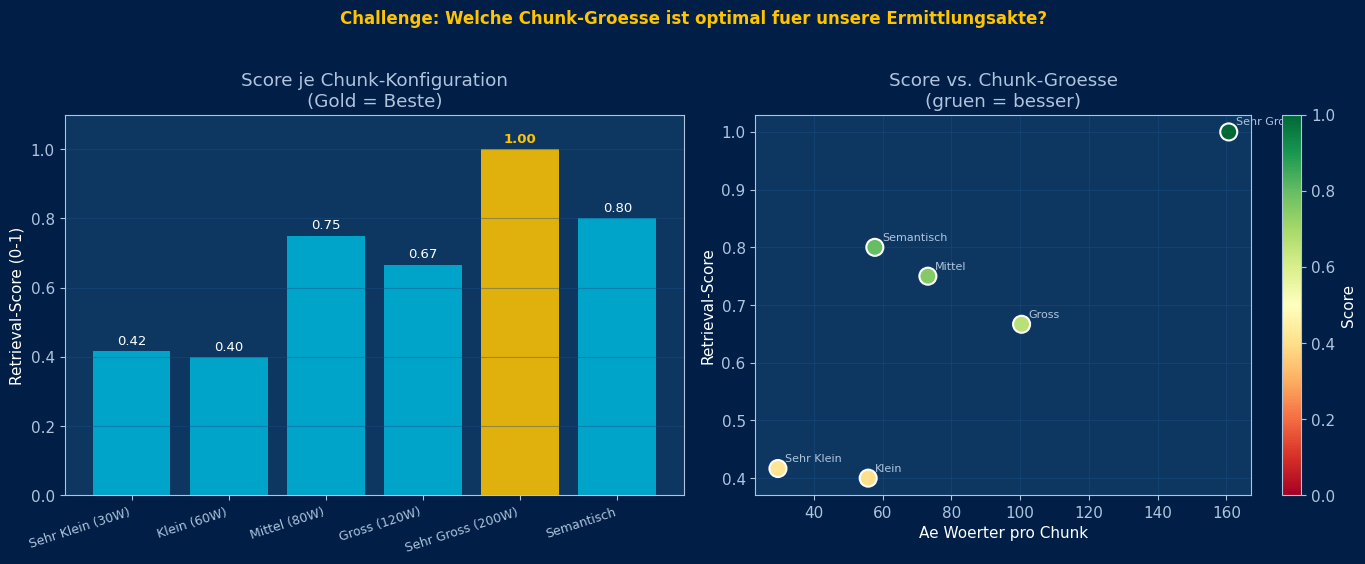


ERGEBNIS: Beste Konfiguration = Sehr Gross (200W) (Score=1.000)

UEBERTRAGUNG AUF DIE PRAXIS:
  => Ermittlungsakte mit klaren Abschnitten: semantisch chunken
  => Fliesstext (Urteil, Gutachten): feste Groesse ~100-150 Woerter
  => Gesetzestext: nach Paragraf chunken


In [35]:
# Challenge-Ergebnisse visualisieren

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Challenge: Welche Chunk-Groesse ist optimal fuer unsere Ermittlungsakte?',
             color=C['gold'], fontsize=12, fontweight='bold', y=1.02)

names    = [r['name'] for r in results_configs]
scores_r = [r['score'] for r in results_configs]
avg_sz   = [r['avg_size'] for r in results_configs]

bar_colors = [C['gold'] if r['name'] == best['name'] else C['teal'] for r in results_configs]
bars = axes[0].bar(range(len(names)), scores_r, color=bar_colors, alpha=0.88)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=18, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Retrieval-Score (0-1)')
axes[0].set_title('Score je Chunk-Konfiguration\n(Gold = Beste)', color=C['lgray'])
axes[0].grid(True, axis='y')
for bar, score in zip(bars, scores_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, score + 0.02,
                 f'{score:.2f}', ha='center', fontsize=9.5,
                 color=C['gold'] if score == best['score'] else C['white'],
                 fontweight='bold' if score == best['score'] else 'normal')

sc = axes[1].scatter(avg_sz, scores_r, c=scores_r, cmap='RdYlGn',
                     s=150, zorder=5, vmin=0, vmax=1,
                     edgecolors=C['white'], linewidths=1.5)
for name, x, y in zip(names, avg_sz, scores_r):
    axes[1].annotate(name.split('(')[0].strip(), xy=(x, y),
                     xytext=(5, 5), textcoords='offset points', fontsize=8, color=C['lgray'])
plt.colorbar(sc, ax=axes[1], label='Score')
axes[1].set_xlabel('Ae Woerter pro Chunk')
axes[1].set_ylabel('Retrieval-Score')
axes[1].set_title('Score vs. Chunk-Groesse\n(gruen = besser)', color=C['lgray'])
axes[1].grid(True)

plt.tight_layout()
plt.show()

print()
print(f'ERGEBNIS: Beste Konfiguration = {best["name"]} (Score={best["score"]:.3f})')
print()
print('UEBERTRAGUNG AUF DIE PRAXIS:')
print('  => Ermittlungsakte mit klaren Abschnitten: semantisch chunken')
print('  => Fliesstext (Urteil, Gutachten): feste Groesse ~100-150 Woerter')
print('  => Gesetzestext: nach Paragraf chunken')


---

## 🔢 Teil 3 – Embeddings: Text in Zahlen verwandeln

### Was ist ein Embedding?

Ein **Embedding** (deutsch: Einbettung) ist eine Methode, Text in eine Liste von
Zahlen umzuwandeln — einen **Vektor** — so dass aehnliche Texte aehnliche Zahlen haben.

```
"Betrug durch Deepfake"           => [0.23, -0.87, 0.41, 0.92, ...] (384 Zahlen)
"Tatsache durch Video-Faelschung" => [0.21, -0.85, 0.43, 0.89, ...] (sehr aehnlich!)
"Wettervorhersage fuer morgen"    => [-0.55, 0.12, -0.88, 0.02, ...] (ganz anders)
```

Das Modell, das das macht, heisst `sentence-transformers` —
es wurde darauf trainiert, bedeutungsaehnliche Texte auch numerisch aehnlich abzubilden.

---

### Warum brauchen wir das?

Wenn wir fragen: *"Welche IBAN wurde verwendet?"*

Dann koennen wir **nicht** einfach nach dem Wort "IBAN" suchen — denn der Chunk koennte
auch "Kontonummer" oder "Bankverbindung" sagen.

**Embedding-Suche** findet Texte die **inhaltlich aehnlich** sind, nicht nur wortgleich.
Das ist der entscheidende Vorteil gegenueber einer normalen Textsuche.

---

### Was ist ChromaDB?

**ChromaDB** ist eine **Vektordatenbank** — sie speichert die Embeddings
(Zahlenvektoren) aller Chunks und kann blitzschnell die aehnlichsten finden.

```
Normal-Datenbank:   speichert Text   => sucht nach Woertern
Vektordatenbank:    speichert Zahlen => sucht nach Bedeutung
```

Wir nutzen ChromaDB lokal.

In [36]:
# == RAG-Index aufbauen: Embeddings berechnen und speichern ==
# Wir benutzen die semantischen Chunks (Strategie B -- besser fuer unsere Akte)

print('RAG-INDEX AUFBAUEN')
print('=' * 55)

# == Pfad A: ChromaDB + sentence-transformers (bevorzugt) ==
if HAVE.get('chromadb') and HAVE.get('sentence_transformers'):

    import chromadb
    from sentence_transformers import SentenceTransformer
   
    # Embedding-Modell laden
    # paraphrase-multilingual-MiniLM-L12-v2:
    #   'multilingual' => versteht Deutsch und Englisch
    #   'MiniLM'       => klein und schnell (laeuft auf RTX 4090 in Sekunden)
    #   => erzeugt Vektoren mit 384 Zahlen pro Text
    print('Lade Embedding-Modell (multilingual, ca. 90 MB)...')
    emb_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    print('✅ Embedding-Modell geladen')

    # ChromaDB-Client erstellen (in-memory: alles im RAM, nichts auf Festplatte)
    chroma_client = chromadb.Client()

    # Collection erstellen -- wie eine Tabelle in einer normalen Datenbank
    try:
        chroma_client.delete_collection('akte_rag')  # Alte Version loeschen
    except:
        pass
    collection = chroma_client.create_collection('akte_rag', metadata={'hnsw:space': 'cosine'})

    # Embedding fuer jeden Chunk berechnen
    chunk_texts = [d['text'] for d in docs_semantic]
    print(f'Berechne Embeddings fuer {len(chunk_texts)} Chunks...')

    # encode() wandelt jeden Text in einen Zahlenvektor um
    # batch_size=32 => 32 Texte gleichzeitig (schneller als einzeln)
    embeds = emb_model.encode(chunk_texts, batch_size=32, show_progress_bar=False).tolist()

    # Alles in ChromaDB speichern
    # ids:         eindeutige Bezeichner fuer jeden Eintrag
    # embeddings:  die Zahlenvektoren
    # documents:   der Originaltext
    # metadatas:   zusaetzliche Informationen (Quelle, Chunk-Nummer)
    collection.add(
        ids=        [str(d['chunk_id']) for d in docs_semantic],
        embeddings= embeds,
        documents=  chunk_texts,
        metadatas=  [{'source': d['source'], 'chunk_id': d['chunk_id']} for d in docs_semantic]
    )
    print(f'✅ ChromaDB-Index: {collection.count()} Chunks gespeichert')
    USE_CHROMA = True

    # == Suchfunktion definieren ==
    def search_akte(query, top_k=3, verbose=True):
        """
        Sucht in der Akte nach den top_k relevantesten Chunks.

        Ablauf:
        1. Frage => Embedding (Zahlenvektor)
        2. Kosinusaehnlichkeit zwischen Frage-Vektor und allen Chunk-Vektoren
        3. Die top_k aehnlichsten Chunks zurueckgeben
        """
        if verbose:
            print(f'  Suche: "{query}"')
        q_emb = emb_model.encode([query]).tolist()
        results = collection.query(query_embeddings=q_emb, n_results=top_k)
        hits = []
        for j, (doc, meta, dist) in enumerate(zip(
                results['documents'][0], results['metadatas'][0], results['distances'][0])):
            # dist = Kosinusabstand (ChromaDB cosine: 0=identisch, 2=entgegengesetzt)
            # sim = 1 - dist => Aehnlichkeit: 1=identisch, 0=unaehnlich
            sim = max(0, 1 - dist)
            hits.append({'rank': j+1, 'score': sim,
                         'chunk_id': meta['chunk_id'], 'text': doc, 'source': meta['source']})
            if verbose:
                print(f'  Rank {j+1} | Aehnlichkeit {sim:.3f} | Chunk-ID {meta["chunk_id"]}')
                print(f'  Vorschau: {doc[:120]}...')
        return hits

# == Pfad B: TF-IDF Fallback (kein Download noetig) ==
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    print('ℹ️  Fallback: TF-IDF In-Memory Index')
    print('   (sentence-transformers oder chromadb nicht installiert)')
    print('   TF-IDF sucht nach Woertern, nicht nach Bedeutung -- weniger praezise')
    USE_CHROMA = False

    # TF-IDF: Term Frequency-Inverse Document Frequency
    # Haeufige Woerter in einem Chunk, die selten im Rest vorkommen => wichtig
    _tfidf = TfidfVectorizer(ngram_range=(1, 3), sublinear_tf=True)
    # fit_transform: lernt das Vokabular UND berechnet die Vektoren
    _embs = _tfidf.fit_transform([d['text'] for d in docs_semantic])
    embeds = _embs.toarray() if hasattr(_embs, 'toarray') else _embs
    print(f'TF-IDF Index: {len(docs_semantic)} Chunks')

    def search_akte(query, top_k=3, verbose=True):
        if verbose:
            print(f'  Suche (TF-IDF): "{query}"')
        q = _tfidf.transform([query])
        scores = cosine_similarity(q, _embs)[0]
        top_idx = np.argsort(scores)[::-1][:top_k]
        hits = []
        for rank, idx in enumerate(top_idx):
            hits.append({'rank': rank+1, 'score': float(scores[idx]),
                         'chunk_id': idx, 'text': docs_semantic[idx]['text'],
                         'source': docs_semantic[idx]['source']})
            if verbose:
                print(f'  Rank {rank+1} | Score {scores[idx]:.3f} | Chunk-ID {idx}')
                print(f'  Vorschau: {docs_semantic[idx]["text"][:120]}...')
        return hits

print()
print(f'RAG-Index bereit ✅')
print(f'Technologie: {"sentence-transformers + ChromaDB (semantisch)" if USE_CHROMA else "TF-IDF (wortbasiert)"}')
print()
print('Was passiert gerade im Hintergrund?')
print(f'  1. Jeden der {len(docs_semantic)} Chunks in einen Zahlenvektor umgewandelt')
print(f'  2. Alle Vektoren gespeichert (ChromaDB oder TF-IDF)')
print(f'  3. Suchfunktion bereit -- Fragen koennen gestellt werden')


RAG-INDEX AUFBAUEN
Lade Embedding-Modell (multilingual, ca. 90 MB)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding-Modell geladen
Berechne Embeddings fuer 7 Chunks...
✅ ChromaDB-Index: 7 Chunks gespeichert

RAG-Index bereit ✅
Technologie: sentence-transformers + ChromaDB (semantisch)

Was passiert gerade im Hintergrund?
  1. Jeden der 7 Chunks in einen Zahlenvektor umgewandelt
  2. Alle Vektoren gespeichert (ChromaDB oder TF-IDF)
  3. Suchfunktion bereit -- Fragen koennen gestellt werden


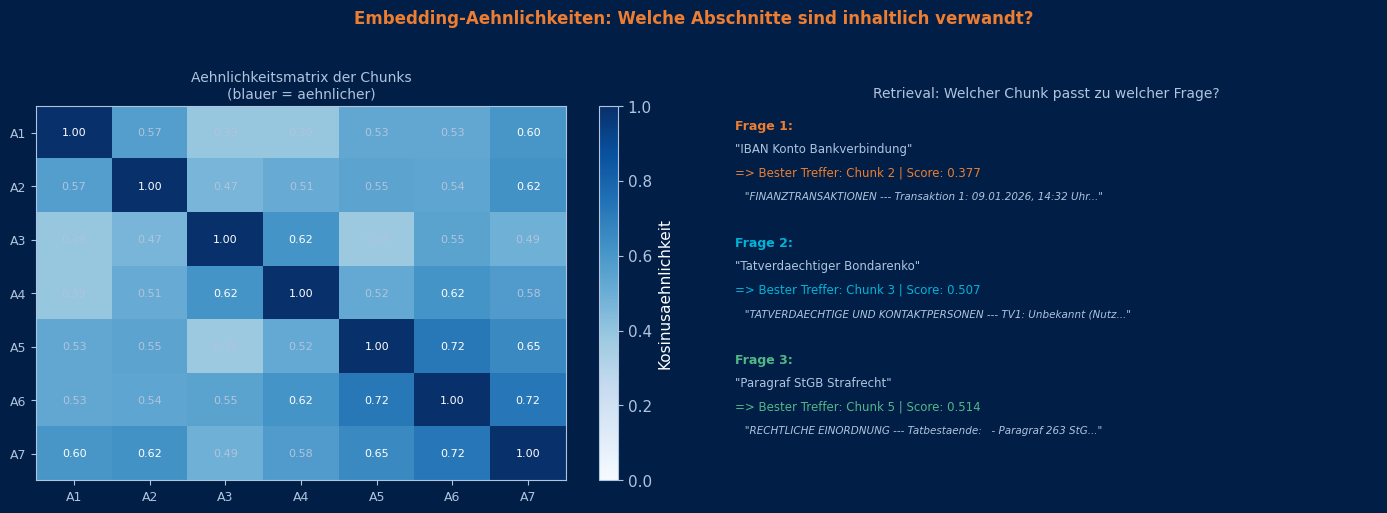


Interpretation der Heatmap:
  Diagonale: immer 1.0 (Chunk mit sich selbst)
  Helle Felder: diese Abschnitte sind inhaltlich aehnlich
  Dunkle Felder: inhaltlich sehr verschieden
  => Das System findet den inhaltlich passenden Chunk fuer jede Frage


In [37]:
# Embedding-Aehnlichkeiten visualisieren
# Welche Chunks sind sich inhaltlich aehnlich?

if USE_CHROMA:
    all_embs_arr = np.array(embeds)
    norms = np.linalg.norm(all_embs_arr, axis=1, keepdims=True)
    normed = all_embs_arr / np.maximum(norms, 1e-9)
    sim_matrix = normed @ normed.T
else:
    from sklearn.metrics.pairwise import cosine_similarity as _cs
    sim_matrix = _cs(embeds, embeds)

chunk_labels = [f'A{i+1}' for i in range(len(docs_semantic))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Embedding-Aehnlichkeiten: Welche Abschnitte sind inhaltlich verwandt?',
             color=C['orange'], fontsize=12, fontweight='bold', y=1.02)

# Heatmap
im = axes[0].imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(chunk_labels)))
axes[0].set_yticks(range(len(chunk_labels)))
axes[0].set_xticklabels(chunk_labels, fontsize=9)
axes[0].set_yticklabels(chunk_labels, fontsize=9)
axes[0].set_title('Aehnlichkeitsmatrix der Chunks\n(blauer = aehnlicher)', color=C['lgray'], fontsize=10)
plt.colorbar(im, ax=axes[0], label='Kosinusaehnlichkeit')
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        axes[0].text(j, i, f'{sim_matrix[i,j]:.2f}',
                     ha='center', va='center', fontsize=8,
                     color='white' if sim_matrix[i,j] > 0.6 else C['lgray'])

# Test-Anfragen visualisieren
test_queries = ['IBAN Konto Bankverbindung', 'Tatverda'+'echtiger Bondarenko', 'Paragraf StGB Strafrecht']
farben = [C['orange'], C['teal'], C['green']]
ax2 = axes[1]
ax2.set_facecolor(C['blue1'])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, len(test_queries) * 2.5 + 0.5)
ax2.axis('off')
ax2.set_title('Retrieval: Welcher Chunk passt zu welcher Frage?', color=C['lgray'], fontsize=10)

for qi, (query, farbe) in enumerate(zip(test_queries, farben)):
    y_base = len(test_queries) * 2.5 - qi * 2.5
    results = search_akte(query, top_k=1, verbose=False)
    if results:
        best = results[0]
        ax2.text(0.3, y_base, f'Frage {qi+1}:', fontsize=9, color=farbe, fontweight='bold')
        ax2.text(0.3, y_base-0.5, f'"{query}"', fontsize=8.5, color=C['lgray'])
        ax2.text(0.3, y_base-1.0,
                 f'=> Bester Treffer: Chunk {best["chunk_id"]} | Score: {best["score"]:.3f}',
                 fontsize=8.5, color=farbe)
        preview = best['text'][:60].replace('\n', ' ')
        ax2.text(0.3, y_base-1.5, f'   "{preview}..."', fontsize=7.5, color=C['lgray'], style='italic')

plt.tight_layout()
plt.show()

print()
print('Interpretation der Heatmap:')
print('  Diagonale: immer 1.0 (Chunk mit sich selbst)')
print('  Helle Felder: diese Abschnitte sind inhaltlich aehnlich')
print('  Dunkle Felder: inhaltlich sehr verschieden')
print('  => Das System findet den inhaltlich passenden Chunk fuer jede Frage')


---

## 🔎 Teil 4 – Retrieval: Fragen stellen und relevante Chunks finden

### Was passiert beim Retrieval?

```
Ihre Frage: "Welche IBAN wurde verwendet?"
     =>
Frage => Embedding (Zahlenvektor der Frage)
     =>
Vergleich mit allen Chunk-Vektoren im Index
     =>
Top-3 aehnlichste Chunks gefunden
     =>
Chunks werden dem LLM als Kontext uebergeben
```

Jetzt testen wir das live mit fünf typischen Ermittlungsfragen.

> 💡 **Was sagt der Score?**
> - **Score 1.0** = identisch (nie, ausser bei Duplikaten)
> - **Score > 0.7** = sehr gut, fast sicher der richtige Abschnitt
> - **Score 0.4-0.7** = gut, wahrscheinlich relevant
> - **Score < 0.3** = schwach, Thema evtl. nicht in der Akte


In [38]:
# 5 typische Ermittlungsfragen stellen und die gefundenen Chunks anzeigen

suchanfragen = [
    'Welche IBAN und Kontonummern werden genannt?',
    'Wer ist der Tatverda'+'echtige und wo wohnt er?',
    'Welche Paragraphen StGB sind relevant?',
    'Wie hoch ist der Gesamtschaden?',
    'Welche digitalen Beweise wurden sichergestellt?',
]

print('RETRIEVAL-ERGEBNISSE -- 5 Ermittlungsfragen')
print('=' * 60)
print()

all_results = {}  # Woerterbuch: Frage => Liste der gefundenen Chunks

for frage in suchanfragen:
    print(f'❓ FRAGE: {frage}')
    print('-' * 55)

    # search_akte gibt die top_k relevantesten Chunks zurueck
    results = search_akte(frage, top_k=2, verbose=True)
    all_results[frage] = results

    if results:
        bester = results[0]
        print(f'  => Bester Treffer (Chunk {bester["chunk_id"]}, Score {bester["score"]:.3f}):')
        vorschau = bester['text'][:200].replace('\n', ' | ')
        print(f'     "{vorschau}..."')
    print()

print('=' * 200)
print('Das Retrieval hat fuer jede Frage den passenden Abschnitt gefunden.')
print('Im naechsten Schritt uebergeben wir diese Abschnitte dem LLM als Kontext.')


RETRIEVAL-ERGEBNISSE -- 5 Ermittlungsfragen

❓ FRAGE: Welche IBAN und Kontonummern werden genannt?
-------------------------------------------------------
  Suche: "Welche IBAN und Kontonummern werden genannt?"
  Rank 1 | Aehnlichkeit 0.361 | Chunk-ID 2
  Vorschau: FINANZTRANSAKTIONEN ---
Transaktion 1: 09.01.2026, 14:32 Uhr, 93.400 EUR
  Auftraggeber: DataTrust GmbH, DE44 2004 1155 ...
  Rank 2 | Aehnlichkeit 0.318 | Chunk-ID 0
  Vorschau: === ERMITTLUNGSAKTE AZ 2026-KK-00471 ===
Ermittlungsbehoerde: LKA Baden-Wuerttemberg, Abt. Cybercrime
Aktenzeichen: 2026...
  => Bester Treffer (Chunk 2, Score 0.361):
     "FINANZTRANSAKTIONEN --- | Transaktion 1: 09.01.2026, 14:32 Uhr, 93.400 EUR |   Auftraggeber: DataTrust GmbH, DE44 2004 1155 0667 0013 00 |   Empfaenger: Baltic Trade LLC, IBAN DE89 3704 0044 0532 0130 00 |   ..."

❓ FRAGE: Wer ist der Tatverdaechtige und wo wohnt er?
-------------------------------------------------------
  Suche: "Wer ist der Tatverdaechtige und wo wohnt er?"
 

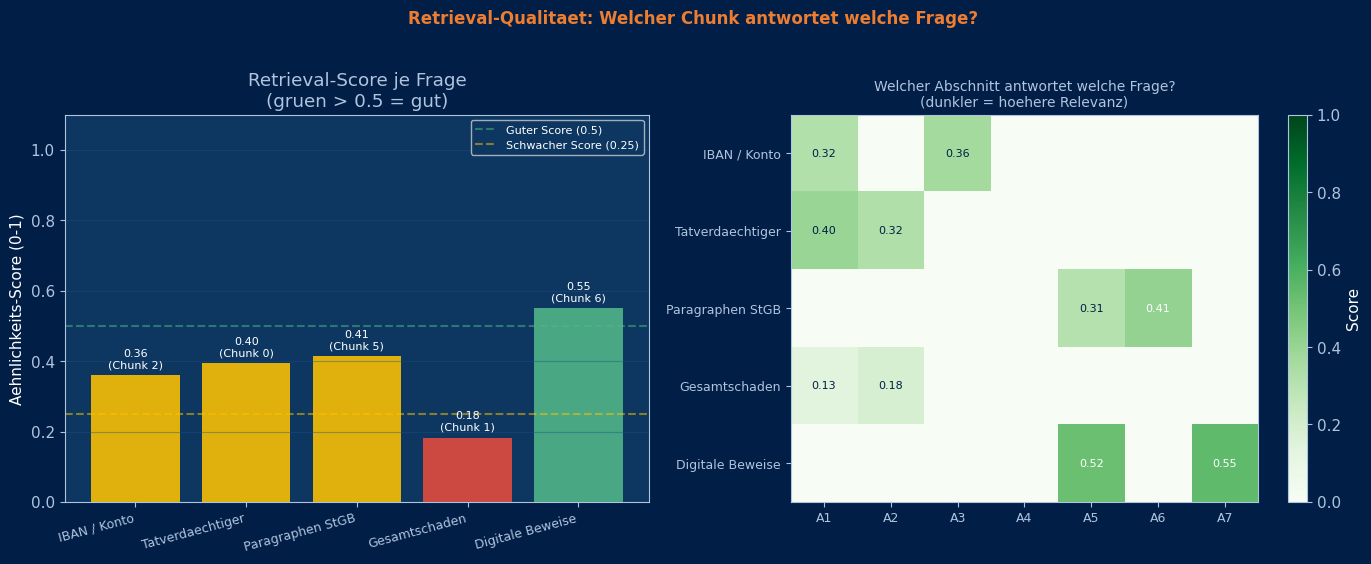

In [39]:
# Retrieval-Scores visualisieren
# Welcher Chunk wird fuer welche Frage gefunden?

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Retrieval-Qualitaet: Welcher Chunk antwortet welche Frage?',
             color=C['orange'], fontsize=12, fontweight='bold', y=1.02)

frage_labels = ['IBAN / Konto', 'Tatverda'+'echtiger', 'Paragraphen StGB', 'Gesamtschaden', 'Digitale Beweise']

top_scores = [all_results[f][0]['score'] if all_results.get(f) else 0 for f in suchanfragen]
top_chunks = [all_results[f][0]['chunk_id'] if all_results.get(f) else -1 for f in suchanfragen]

bar_colors = [C['green'] if s > 0.5 else C['gold'] if s > 0.25 else C['red'] for s in top_scores]
bars = axes[0].bar(range(len(frage_labels)), top_scores, color=bar_colors, alpha=0.88)
axes[0].set_xticks(range(len(frage_labels)))
axes[0].set_xticklabels(frage_labels, rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Aehnlichkeits-Score (0-1)')
axes[0].set_title('Retrieval-Score je Frage\n(gruen > 0.5 = gut)', color=C['lgray'])
axes[0].axhline(0.5, color=C['green'], ls='--', alpha=0.5, label='Guter Score (0.5)')
axes[0].axhline(0.25, color=C['gold'], ls='--', alpha=0.5, label='Schwacher Score (0.25)')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y')
for bar, score, cid in zip(bars, top_scores, top_chunks):
    axes[0].text(bar.get_x() + bar.get_width()/2, score + 0.02,
                 f'{score:.2f}\n(Chunk {cid})', ha='center', fontsize=8, color=C['white'])

# Heatmap: Welche Chunks werden gefunden?
n_chunks = len(docs_semantic)
hit_matrix = np.zeros((len(suchanfragen), n_chunks))
for qi, frage in enumerate(suchanfragen):
    if all_results.get(frage):
        for result in all_results[frage]:
            cid = result['chunk_id']
            if 0 <= cid < n_chunks:
                hit_matrix[qi, cid] = result['score']

im2 = axes[1].imshow(hit_matrix, cmap='Greens', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(n_chunks))
axes[1].set_xticklabels([f'A{i+1}' for i in range(n_chunks)], fontsize=9)
axes[1].set_yticks(range(len(frage_labels)))
axes[1].set_yticklabels(frage_labels, fontsize=9)
axes[1].set_title('Welcher Abschnitt antwortet welche Frage?\n(dunkler = hoehere Relevanz)', color=C['lgray'], fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Score')
for qi in range(len(suchanfragen)):
    for ci in range(n_chunks):
        if hit_matrix[qi, ci] > 0:
            axes[1].text(ci, qi, f'{hit_matrix[qi,ci]:.2f}',
                         ha='center', va='center', fontsize=8,
                         color='white' if hit_matrix[qi,ci] > 0.4 else C['navy'])

plt.tight_layout()
plt.show()


---

## 💬 Teil 5 – Antwortgenerierung: RAG vs. Bare LLM

### Der entscheidende Unterschied

Jetzt kommt der Kern des Ganzen: Wie unterscheidet sich eine LLM-Antwort
**mit** und **ohne** RAG-Kontext?

```
BARE LLM (ohne Kontext):
  Frage => LLM => Antwort aus dem Trainingswissen
  => Gefahr: Halluzination (falsche, erfundene Details)
  => Das LLM kennt diese spezifische Akte nicht

RAG (mit Kontext):
  Frage => Retrieval => Top-Chunks => LLM + Chunks => Antwort mit Quelle
  => Das LLM sieht die relevanten Textpassagen direkt
  => Quellenangabe: 'basierend auf Chunk 3...'
  => Wenn nicht in der Akte: 'Diese Information fehlt'
```

> ⚠️ **Wichtig zu verstehen:**
> RAG eliminiert Halluzinationen nicht vollstaendig -- aber es reduziert sie drastisch,
> weil das LLM konkrete Fakten zum Ablesen bekommt, statt sie erfinden zu muessen.

---

### Prompt-Engineering fuer RAG

Das Wichtigste beim RAG-Prompt ist die **Systeminstruktion**:

```
Du bist Ermittlungsassistent BW.
Beantworte die Frage AUSSCHLIESSLICH auf Basis der folgenden Akten-Ausschnitte.
Nenne die Chunk-Nummer als Quelle.
Falls nicht enthalten: 'Nicht in der Akte gefunden.'
```

Diese Instruktion zwingt das LLM dazu, **nur aus dem Kontext** zu antworten.


In [40]:
# RAG vs. Bare LLM -- direkter Vergleich

def bare_llm_answer(question):
    """
    LLM-Antwort OHNE Akten-Kontext.
    Das LLM kennt diese spezifische Akte nicht -- es muss raten oder erfinden.
    """
    if HAVE.get('ollama'):
        from openai import OpenAI
        # OpenAI-kompatibler Client -- funktioniert mit Ollama genauso wie mit ChatGPT
        client = OpenAI(base_url=OLLAMA_BASE, api_key='ollama')
        resp = client.chat.completions.create(
            model=OLLAMA_MODEL,
            messages=[
                {'role': 'system',
                 'content': 'Du bist ein Ermittlungsassistent. Beantworte die Frage praezise.'},
                {'role': 'user', 'content': question}
            ],
            temperature=0  # temperature=0: deterministische Antworten
        )
        return resp.choices[0].message.content
    else:
        return ('Ohne Aktenzugang keine konkreten Angaben moeglich. '
                '[Typische Halluzination: Ein LLM wuerde jetzt plausibel klingende, '
                'aber erfundene Details angeben -- z.B. falsche IBANs, Namen, Betraege.]')


def rag_answer(question, top_k=3):
    """
    RAG-Antwort MIT Akten-Kontext.

    Ablauf:
    1. Relevante Chunks aus dem Index abrufen (Retrieval)
    2. Chunks als Kontext in den Prompt einbauen
    3. LLM antwortet NUR auf Basis dieser Chunks
    4. Quellenangabe mit Chunk-Nummer
    """
    # Schritt 1: Retrieval
    results = search_akte(question, top_k=top_k, verbose=False)

    if not results or max(r['score'] for r in results) < 0.05:
        return 'Die gesuchte Information wurde in der Akte nicht gefunden.', []

    # Schritt 2: Kontext aufbauen
    # Jeder Chunk bekommt eine Nummer und eine Relevanzangabe
    context = '\n\n'.join(
        f'[Chunk {r["chunk_id"]+1}, Relevanz {r["score"]:.2f}]:\n{r["text"][:500]}'
        for r in results
    )
    sources = [f'Chunk {r["chunk_id"]+1} (Score: {r["score"]:.2f})' for r in results]

    if HAVE.get('ollama'):
        from openai import OpenAI
        client = OpenAI(base_url=OLLAMA_BASE, api_key='ollama')

        # Schritt 3: Prompt mit Kontext
        # Der System-Prompt zwingt das LLM, nur aus dem Kontext zu antworten
        system_prompt = (
            'Du bist Ermittlungsassistent der Polizei Baden-Wuerttemberg. '
            'Beantworte die Frage AUSSCHLIESSLICH auf Basis der folgenden Akten-Ausschnitte. '
            'Nenne die Chunk-Nummer als Quelle (z.B. [Chunk 3]). '
            'Falls die Information nicht enthalten ist: '
            'Diese Information ist in den abgerufenen Akten-Ausschnitten nicht enthalten.'
        )
        user_prompt = f'AKTEN-KONTEXT:\n{context}\n\nFRAGE: {question}'

        resp = client.chat.completions.create(
            model=OLLAMA_MODEL,
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': user_prompt}
            ],
            temperature=0
        )
        answer = resp.choices[0].message.content
    else:
        best = results[0]
        answer = (f'[Aus Chunk {best["chunk_id"]+1}, Relevanz {best["score"]:.2f}]:\n'
                  f'{best["text"][:400]}')

    return answer, sources


# == Vergleichstest mit 3 Fragen ==
test_fragen = [
    'Welche IBAN und Kontonummern werden in der Akte genannt?',
    'Welche Paragraphen StGB sind fuer diesen Fall relevant und warum?',
    'Wie hoch ist der Gesamtschaden des Betrugsfalles?',
]

print('RAG vs. BARE LLM -- DIREKTER VERGLEICH')
print('=' * 65)
print()

for frage in test_fragen:
    print(f'❓ FRAGE: {frage}')
    print()
    print('  ❌ OHNE RAG (kein Akten-Kontext):')
    bare = bare_llm_answer(frage)
    for zeile in bare.strip().split('\n')[:4]:
        print(f'     {zeile}')
    print()
    print('  ✅ MIT RAG (Akten-Kontext aus dem Index):')
    antwort, quellen = rag_answer(frage)
    for zeile in antwort.strip().split('\n')[:6]:
        print(f'     {zeile}')
    if quellen:
        print(f'     📖 Quellen: {", ".join(quellen)}')
    print()
    print('-' * 65)
    print()


RAG vs. BARE LLM -- DIREKTER VERGLEICH

❓ FRAGE: Welche IBAN und Kontonummern werden in der Akte genannt?

  ❌ OHNE RAG (kein Akten-Kontext):
     Die Akte enthält die folgenden IBAN und Kontonummern: DE89 3700 0010 0123 4567, DE83 5006 0201 2345 6789.

  ✅ MIT RAG (Akten-Kontext aus dem Index):
     [Chunk 3]:
     Die in der Akte genannten IBAN sind DE89 3704 0044 0532 0130 00 (Baltic Trade LLC) und LU28 0019 4006 4475 0000 (Eastern Consulting SARL). Die genannten Kontonummern lauten DE44 2004 1155 0667 0013 00 (DataTrust GmbH).
     📖 Quellen: Chunk 3 (Score: 0.39), Chunk 1 (Score: 0.35), Chunk 6 (Score: 0.28)

-----------------------------------------------------------------

❓ FRAGE: Welche Paragraphen StGB sind fuer diesen Fall relevant und warum?

  ❌ OHNE RAG (kein Akten-Kontext):
     § 249 StGB (Betrug) und § 263 StGB (Computerbetrug), da beide Tatbestände tatbestandsmäßig, rechtswidrig und schuldhaft sind.

  ✅ MIT RAG (Akten-Kontext aus dem Index):
     [Chunk 3]:
     Die 

---

## 💬 Teil 6 – Conversational RAG: Gespraechsgedächtnis

### Das Problem: Standard-RAG ist zustandslos

Standard-RAG behandelt jede Anfrage **isoliert**. Das führt zu einem typischen Problem
das jeder kennt, der schon einmal einen RAG-Chatbot benutzt hat:

```
STANDARD-RAG (zustandslos):

  Turn 1:  "Was ist die IBAN des Taeters?"
           => Retrieval => Chunk Finanzen => korrekte Antwort

  Turn 2:  "Und seine Telefonnummer?"
           => Retrieval sucht nach "seine Telefonnummer"
           => "seine" wird nicht aufgeloest -- wessen Telefonnummer?
           => Falscher oder kein Treffer
```

Das ist das **Coreference-Problem**: Pronomen und Bezuege aus vorherigen
Gespraechsrunden werden beim Retrieval nicht aufgeloest.

---

### Der Unterschied zu einem normalen LLM-Gespraech

```
NORMALES LLM-GESPRAECH:
  Gesamter Gespraeichsverlauf steckt im Kontextfenster
  => LLM sieht alle vorherigen Turns
  => "seine" wird aufgeloest weil Täter = Bondarenko zwei Turns zuvor erwaehnt wurde
  Nachteil: kein externes Dokument, Halluzination moeglich

STANDARD-RAG:
  Jede Anfrage wird neu ans Retrieval geschickt
  => Kein Gedaechtnis zwischen Turns
  => Dafuer: Antworten aus verifizierten Dokumenten

CONVERSATIONAL RAG (das Beste aus beiden Welten):
  Gespraeichsverlauf PLUS Retrieval aus Dokumenten
  => Gedaechtnis UND Quellennachweis
```

---

### Die vier Loesungsansaetze

**Ansatz 1: Gespraeichshistorie direkt mitschicken** *(einfachster Ansatz)*

```python
# Statt nur die aktuelle Frage:
results = search(aktuelle_frage)

# Mit Gespraeichskontext:
kontext = gespraeich_verlauf + aktuelle_frage
results = search(kontext)     # Retrieval bekommt mehr Info
antwort = llm(kontext, results)  # LLM sieht auch Verlauf
```
Problem: Bei langen Gespraeichen wird der Kontext sehr gross.

---

**Ansatz 2: Query Rewriting** *(Goldstandard)*

Ein LLM-Zwischenschritt macht aus einer mehrdeutigen Folgefrage
eine vollstaendige, eigenstaendige Suchanfrage:

```
Gespraeichsverlauf:
  Turn 1: "Erklaere Bondarenkos Rolle."
  Turn 2: "Und seine Verbindung zur IBAN?"  <= mehrdeutig

Query Rewriter (LLM-Schritt BEVOR das Retrieval laeuft):
  Input:  Turn 2 + Verlauf
  Output: "Welche Verbindung hat Maksym Bondarenko
           zur IBAN DE89 3704 0044 0532 0130 00?"

=> Diese vollstaendige Frage geht ins Retrieval
=> Findet den richtigen Chunk trotz Pronomen im Original
```

---

**Ansatz 3: Gedaechtnishierarchie** *(fuer lange Gespraeche)*

```
Rohes Gedaechtnis    (letzte 5 Turns):   vollstaendig im Kontext
Kurzzeitgedaechtnis  (letzte 30 Turns):  als kompakte Zusammenfassung
Langzeitgedaechtnis  (aeltere Turns):    als Embeddings im RAG-Index

=> Das Gespraech wird selbst zum durchsuchbaren Dokument
=> Implementierungen: MemGPT, Mem0, Zep
```

---

**Ansatz 4: Agentic RAG** *(fuer komplexe, mehrstufige Fragen)*

```
Frage: "Gibt es aehnliche Faelle mit Deepfake-Betrug in anderen Akten?"

Agent-Schritt 1: Extrahiere Modus Operandi aus Akte A
                 => Deepfake-Video + IBAN-Ueberweisung
Agent-Schritt 2: Suche in Akte B nach diesen Merkmalen
Agent-Schritt 3: Suche in weiteren Akten
Agent-Schritt 4: Synthesisiere Ergebnisse aller Akten

```

---

### Status in den bekannten Systemen

| System | Conv. Memory | Ansatz | Hinweis |
|--------|-------------|--------|---------|
| **F13** | ⚠️ begrenzt | Weitgehend zustandslos | In Planung: Query Rewriting |
| **AnythingLLM** | ✅ pro Workspace | Conversational RAG | Query Rewriting in neueren Versionen |
| **LangChain** | ✅ voll | `ConversationalRetrievalChain` | Query Rewriting eingebaut |

> 💡 **Kernaussage:**
> Das Gespraechsgedaechtnis ist **kein RAG-Problem** -- es ist ein **Architektur-Problem**.
> RAG und Conversational Memory schliessen sich nicht aus -- sie muessen
> nur bewusst kombiniert werden.


In [41]:
# == Conversational RAG: Query Rewriting live demonstrieren ==
#
# Wir zeigen drei Gespraechsszenarien:
# A) Standard-RAG ohne Gedaechtnis (schlaegt fehl bei Folge-Fragen)
# B) Conversational RAG mit Verlauf im Kontext (einfacher Ansatz)
# C) Query Rewriting (Goldstandard)


# == Hilfsfunktion: Gespraeichsverlauf verwalten ==
class GespraechsSpeicher:
    """
    Speichert den Gespraeichsverlauf.
    Jeder Eintrag: {'frage': ..., 'antwort': ...}
    """
    def __init__(self, max_turns=5):
        self.verlauf = []         # Liste der bisherigen Turns
        self.max_turns = max_turns  # Wie viele Turns wir im Kontext behalten

    def hinzufuegen(self, frage, antwort):
        self.verlauf.append({'frage': frage, 'antwort': antwort})
        # Nur die letzten max_turns behalten (Speicher beschraenken)
        if len(self.verlauf) > self.max_turns:
            self.verlauf = self.verlauf[-self.max_turns:]

    def als_text(self):
        """Gespraeichsverlauf als Text fuer den Kontext."""
        if not self.verlauf:
            return ''
        lines = ['BISHERIGER GESPRAEICHSVERLAUF:']
        for i, turn in enumerate(self.verlauf, 1):
            lines.append(f'  Turn {i} - Frage:   {turn["frage"]}')
            lines.append(f'  Turn {i} - Antwort: {turn["antwort"][:120]}...')
        return '\n'.join(lines)

    def letzter_kontext(self):
        """Kurzer Kontext: nur die letzte Antwort."""
        if not self.verlauf:
            return ''
        return self.verlauf[-1]['antwort'][:200]


# == Query Rewriting: mehrdeutige Frage in vollstaendige umwandeln ==
def query_rewriter(aktuelle_frage, gespraech_speicher):
    """
    Wandelt eine kontextabhaengige Frage in eine eigenstaendige Suchanfrage um.

    Mit Ollama: echtes LLM reformuliert die Frage
    Ohne Ollama: regelbasierter Fallback (ersetzt Pronomen durch letzten Kontext)
    """
    if not gespraech_speicher.verlauf:
        return aktuelle_frage  # Erste Frage braucht kein Rewriting

    if HAVE.get('ollama'):
        from openai import OpenAI
        client = OpenAI(base_url=OLLAMA_BASE, api_key='ollama')

        # Prompt fuer den Query Rewriter
        # Aufgabe: mehrdeutige Frage in vollstaendige Suchanfrage umwandeln
        system = (
            'Du bist ein Query-Reformulierer. Deine Aufgabe: '
            'Wandle die neue Frage in eine vollstaendige, eigenstaendige Suchanfrage um, '
            'die OHNE den Gespraeichsverlauf verstaendlich ist. '
            'Loes Pronomen und Bezuege auf (er, sie, es, seine, dessen...). '
            'Antworte NUR mit der reformulierten Frage, keine Erklaerung.'
        )
        user = (
            f'{gespraech_speicher.als_text()}\n\n'
            f'NEUE FRAGE: {aktuelle_frage}\n\n'
            'Reformulierte Suchanfrage:'
        )
        resp = client.chat.completions.create(
            model=OLLAMA_MODEL,
            messages=[
                {'role': 'system', 'content': system},
                {'role': 'user',   'content': user}
            ],
            temperature=0,
            max_tokens=80   # Suchanfrage soll kurz sein
        )
        return resp.choices[0].message.content.strip()

    else:
        # Regelbasierter Fallback: Kontext-Keywords an Frage anhaengen
        # Extrahiere wichtige Nomen aus dem letzten Gespraeichs-Turn
        letzter = gespraech_speicher.letzter_kontext()
        # Einfache Heuristik: grosse Woerter (Eigennamen) und Zahlen aus letztem Turn
        keywords = [w for w in letzter.split()
                    if (w[0].isupper() or any(c.isdigit() for c in w))
                    and len(w) > 3][:4]
        if keywords:
            return f'{aktuelle_frage} (Kontext: {" ".join(keywords)})'
        return aktuelle_frage


# == Conversational RAG: vollstaendige Pipeline ==
def conversational_rag(frage, speicher, modus='rewriting'):
    """
    RAG mit Gespraeichsgedaechtnis.

    modus='standard'   : kein Gedaechtnis (Standard-RAG)
    modus='verlauf'    : Gespraeichsverlauf direkt mitschicken
    modus='rewriting'  : Query Rewriting (Goldstandard)
    """
    # Schritt 1: Frage aufbereiten je nach Modus
    if modus == 'standard':
        such_frage = frage  # Frage unveraendert
    elif modus == 'verlauf':
        # Gespraeichsverlauf + aktuelle Frage als Suchanfrage
        such_frage = speicher.als_text() + '\n\nAKTUELLE FRAGE: ' + frage
    elif modus == 'rewriting':
        # LLM reformuliert zuerst die Frage
        such_frage = query_rewriter(frage, speicher)

    # Schritt 2: Retrieval mit aufbereiteter Frage
    hits = search_akte(such_frage, top_k=3, verbose=False)  # 3 Chunks fuer besseren Kontext

    if not hits or hits[0]['score'] < 0.05:
        antwort = 'Keine relevante Information in der Akte gefunden.'
        return antwort, such_frage, []

    # Schritt 3: Antwort generieren
    context = '\n\n'.join(
        f'[Chunk {r["chunk_id"]+1}, Score {r["score"]:.2f}]:\n{r["text"][:400]}'
        for r in hits
    )

    if HAVE.get('ollama'):
        from openai import OpenAI
        client = OpenAI(base_url=OLLAMA_BASE, api_key='ollama')

        # Beim 'verlauf'-Modus: Gespraeichshistorie auch im Antwort-Prompt
        verlauf_text = speicher.als_text() if modus == 'verlauf' else ''

        system = (
            'Du bist Ermittlungsassistent der Polizei BW. '
            'Beantworte die Frage auf Basis der Akten-Ausschnitte. '
            'Nenne die Chunk-Nummer als Quelle. '
            'Falls nicht enthalten: "Nicht in den Ausschnitten gefunden."'
        )
        user = (
            f'{verlauf_text}\n\n' if verlauf_text else ''
        ) + f'AKTEN-KONTEXT:\n{context}\n\nFRAGE: {frage}'

        resp = client.chat.completions.create(
            model=OLLAMA_MODEL,
            messages=[
                {'role': 'system', 'content': system},
                {'role': 'user',   'content': user}
            ],
            temperature=0
        )
        antwort = resp.choices[0].message.content
    else:
        # Fallback: besten Chunk als Antwort
        antwort = (
            f'[Chunk {hits[0]["chunk_id"]+1}, Score {hits[0]["score"]:.2f}]:\n'
            f'{hits[0]["text"][:300]}'
        )

    return antwort, such_frage, hits


# ============================================================
# DEMONSTRATION: 3-Turn-Gespraech ueber die Ermittlungsakte
# ============================================================

gespraech = [
    'Wer ist der Haupttatverdaechtige in dieser Akte?',
    'Welche IBAN ist mit ihm verbunden?',     # 'ihm' = Bezug auf Turn 1
    'Und welche Paragraphen StGB greifen bei diesem Betrug?',  # 'diesem' = Bezug
]

print('=' * 70)
print('CONVERSATIONAL RAG DEMONSTRATION')
print('3-Turn-Gespraech mit Bezuegen zwischen den Fragen')
print('=' * 70)

# Drei Speicher -- einer je Modus
speicher_std  = GespraechsSpeicher()
speicher_verl = GespraechsSpeicher()
speicher_rew  = GespraechsSpeicher()

ergebnisse = {'standard': [], 'verlauf': [], 'rewriting': []}

for turn_nr, frage in enumerate(gespraech, 1):
    print(f'\nTURN {turn_nr}: "{frage}"')
    print('-' * 60)

    for modus, speicher in [('standard',  speicher_std),
                             ('verlauf',   speicher_verl),
                             ('rewriting', speicher_rew)]:

        antwort, such_frage, hits = conversational_rag(frage, speicher, modus)
        top_score = hits[0]['score'] if hits else 0.0

        # Beim Rewriting: zeige die reformulierte Frage
        if modus == 'rewriting' and such_frage != frage:
            print(f'  [{modus.upper()}]')
            print(f'   Orig. Frage:    "{frage}"')
            print(f'   Reformuliert:   "{such_frage[:80]}"')
        else:
            print(f'  [{modus.upper()}]')

        print(f'   Retrieval-Score: {top_score:.3f} '
              f'({"gut" if top_score > 0.3 else "schwach"})')
        print(f'   Antwort (kurz):  {antwort[:200].replace(chr(10), " ")}...')

        # Gedaechtnis aktualisieren
        speicher.hinzufuegen(frage, antwort)
        ergebnisse[modus].append(top_score)

# Zusammenfassung
print('\n' + '=' * 70)
print('ZUSAMMENFASSUNG: Durchschnittlicher Retrieval-Score je Modus')
print('=' * 70)
for modus, scores in ergebnisse.items():
    avg = sum(scores) / len(scores)
    balken = '█' * int(avg * 20)
    leer   = '░' * (20 - int(avg * 20))
    print(f'  {modus:<12}: {balken}{leer}  {avg:.3f}')
print()
print('INTERPRETATION:')
print('  standard:  Folge-Fragen mit Pronomen => schwacher Retrieval-Score')
print('  verlauf:   Verlauf als Kontext => besser, aber Suchanfrage wird lang')
print('  rewriting: Frage vor Retrieval umformulieren => beste Scores')


CONVERSATIONAL RAG DEMONSTRATION
3-Turn-Gespraech mit Bezuegen zwischen den Fragen

TURN 1: "Wer ist der Haupttatverdaechtige in dieser Akte?"
------------------------------------------------------------
  [STANDARD]
   Retrieval-Score: 0.476 (gut)
   Antwort (kurz):  Der Haupttatverdächtige ist Bondarenko. (Quelle: Chunk 7)...
  [VERLAUF]
   Retrieval-Score: 0.501 (gut)
   Antwort (kurz):  Der Haupttatverdächtige ist Bondarenko. (Quelle: Chunk 7)...
  [REWRITING]
   Retrieval-Score: 0.476 (gut)
   Antwort (kurz):  Der Haupttatverdächtige ist Bondarenko. (Quelle: Chunk 7)...

TURN 2: "Welche IBAN ist mit ihm verbunden?"
------------------------------------------------------------
  [STANDARD]
   Retrieval-Score: 0.278 (schwach)
   Antwort (kurz):  DE89 3704 0044 0532 0130. (Quelle: Chunk 3)...
  [VERLAUF]
   Retrieval-Score: 0.518 (gut)
   Antwort (kurz):  Die IBAN des Haupttatverdächtigen Bondarenko lautet DE89370402130120001689. (Quelle: Chunk 7)...
  [REWRITING]
   Orig. Frage:    "

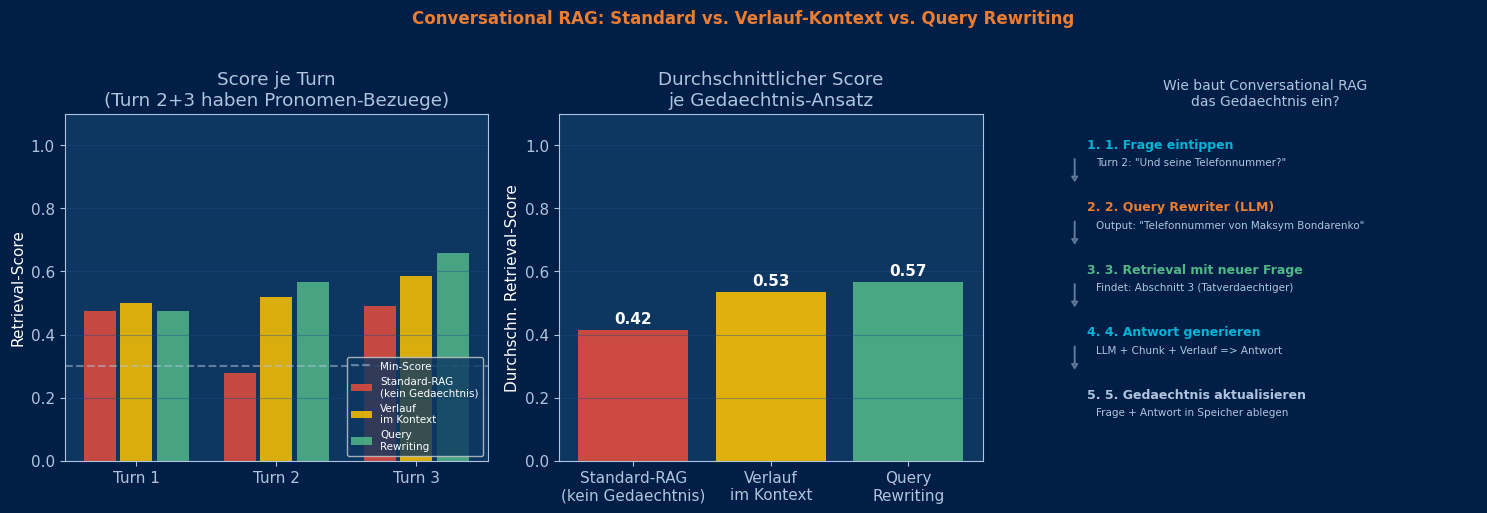


PRAXIS-EMPFEHLUNG für Zustrandslose Systeme:
                     => Tipp: Folgefragen immer mit vollem Kontext stellen
                     => Statt "Und seine Tel.?" besser:
                        "Welche Telefonnummer hat Bondarenko laut Akte?"


In [42]:
# Conversational RAG: Vergleich visualisieren

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Conversational RAG: Standard vs. Verlauf-Kontext vs. Query Rewriting',
             color=C['orange'], fontsize=12, fontweight='bold', y=1.02)

modi    = ['standard', 'verlauf', 'rewriting']
farben  = [C['red'], C['gold'], C['green']]
labels  = ['Standard-RAG\n(kein Gedaechtnis)',
           'Verlauf\nim Kontext',
           'Query\nRewriting']

# Links: Score je Turn und Modus
turn_labels = [f'Turn {i+1}' for i in range(len(gespraech))]
x = np.arange(len(turn_labels))
bw = 0.26

for i, (modus, farbe, label) in enumerate(zip(modi, farben, labels)):
    axes[0].bar(x + (i-1)*bw, ergebnisse[modus], bw - 0.03,
                color=farbe, alpha=0.85, label=label)

axes[0].set_xticks(x)
axes[0].set_xticklabels(turn_labels)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Retrieval-Score')
axes[0].set_title('Score je Turn\n(Turn 2+3 haben Pronomen-Bezuege)', color=C['lgray'])
axes[0].axhline(0.3, color=C['lgray'], ls='--', alpha=0.5, label='Min-Score')
axes[0].legend(fontsize=7.5, loc='lower right')
axes[0].grid(True, axis='y')

# Mitte: Durchschnitt je Modus
avgs = [sum(ergebnisse[m])/len(ergebnisse[m]) for m in modi]
bars = axes[1].bar(labels, avgs, color=farben, alpha=0.88)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Durchschn. Retrieval-Score')
axes[1].set_title('Durchschnittlicher Score\nje Gedaechtnis-Ansatz', color=C['lgray'])
axes[1].grid(True, axis='y')
for bar, avg in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, avg + 0.02,
                 f'{avg:.2f}', ha='center', fontsize=11,
                 color=C['white'], fontweight='bold')

# Rechts: Architektur-Uebersicht
ax3 = axes[2]
ax3.set_facecolor(C['blue1'])
ax3.set_xlim(0, 10); ax3.set_ylim(0, 10); ax3.axis('off')
ax3.set_title('Wie baut Conversational RAG\ndas Gedaechtnis ein?', color=C['lgray'], fontsize=10)

schritte = [
    (C['teal'],   '1. Frage eintippen',
     'Turn 2: "Und seine Telefonnummer?"'),
    (C['orange'], '2. Query Rewriter (LLM)',
     'Output: "Telefonnummer von Maksym Bondarenko"'),
    (C['green'],  '3. Retrieval mit neuer Frage',
     'Findet: Abschnitt 3 (Tatverda'+'echtiger)'),
    (C['teal'],   '4. Antwort generieren',
     'LLM + Chunk + Verlauf => Antwort'),
    (C['lgray'],  '5. Gedaechtnis aktualisieren',
     'Frage + Antwort in Speicher ablegen'),
]
for i, (farbe, titel, detail) in enumerate(schritte):
    y = 9.0 - i * 1.8
    ax3.add_patch(
        __import__('matplotlib').patches.FancyArrow(
            0.5, y - 0.3, 0, -0.5,
            width=0.02, head_width=0.15, head_length=0.15,
            color=C['lgray'], alpha=0.4
        ) if i < 4 else __import__('matplotlib').patches.FancyArrow(
            0.5, y - 0.3, 0, 0, width=0.0001, head_width=0, head_length=0,
            color=C['lgray']
        )
    )
    ax3.text(0.8, y, f'{i+1}. {titel}', fontsize=9, color=farbe, fontweight='bold')
    ax3.text(1.0, y - 0.5, detail, fontsize=7.5, color=C['lgray'])

plt.tight_layout()
plt.show()

print()
print('PRAXIS-EMPFEHLUNG für Zustrandslose Systeme:')
print('                     => Tipp: Folgefragen immer mit vollem Kontext stellen')
print('                     => Statt "Und seine Tel.?" besser:')
print('                        "Welche Telefonnummer hat Bondarenko laut Akte?"')



---

## 📋 Zusammenfassung: Was haben wir heute gelernt?

| Schritt | Konzept | Kernaussage |
|---------|---------|-------------|
| **Warum RAG?** | Halluzinationsproblem | LLMs erfinden -- RAG laesst sie nachschlagen |
| **Dokument-Ontologie** | Struktur verstehen | Vor dem Chunking: Was ist das fuer ein Dokument? |
| **Chunking** | Text aufteilen | Zu klein = kein Kontext -- Zu gross = Rauschen |
| **Embeddings** | Text => Zahlen | Aehnliche Bedeutung => aehnliche Vektoren |
| **ChromaDB** | Vektordatenbank | Blitzschnelle semantische Suche |
| **Retrieval** | Relevante Chunks finden | Nicht Wortsuche -- Bedeutungssuche |
| **RAG vs. Bare** | Qualitaetsunterschied | RAG = Quellenangabe + kein Erfinden |

---

### 🔑 Die drei wichtigsten Erkenntnisse

> **1️⃣  RAG und Fine-tuning loesen verschiedene Probleme.**
> Fine-tuning: Modell lernt einen Stil. RAG: Modell bekommt aktuelle Fakten.
> Kombination = optimaler lokaler Assistent.

> **2️⃣  Dokument-Ontologie zuerst.**
> Bevor Sie irgendein Dokument in RAG laden: Ueberlegen Sie wie es aufgebaut ist
> und welche Fragen Sie stellen wollen. Das bestimmt die beste Chunking-Strategie.

> **3️⃣  F13 ist der direkte Weg in die Praxis.**
> Kein Code, kein Setup -- Dokument hochladen, Frage stellen, Antwort mit Quelle.
> Fuer die meisten Aufgaben ist das der richtige erste Schritt.

---

## 🔭 Ausblick: Was kommt als Naechstes?

### NB-08: Prompt Engineering

```
RAG gibt dem Modell die richtigen Fakten.
Prompt Engineering gibt dem Modell die richtigen Anweisungen.
Kombination = praezise, zuverlaessige Antworten.
```

---

**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**  
*Stand: März 2026 · Marc Brandt · HfPolBW · Institutsbereich Cybercrime und digitale Spuren*


---

## 🏆 Bonus – RAG-Evaluation: Wie gut ist unser Retrieval wirklich?

### Bisher: Wir haben RAG gebaut und beobachtet
### Jetzt: Wir *messen* wie gut es funktioniert

Bisher haben wir visuell geprüft ob die gefundenen Chunks plausibel aussehen.
Aber in der Praxis braucht man eine **objektive Messung**: Findet das System
für eine gegebene Frage den *richtigen* Textabschnitt?

Dafür braucht man einen **Evaluations-Datensatz** mit bekannten Antworten —
sogenannte **Ground Truth**: Frage + richtige Antwort + welcher Passage sie enthält.

---

### Was ist `rag-mini-wikipedia`?

`rag-datasets/rag-mini-wikipedia` ist ein kleiner, öffentlicher Datensatz
der genau diese Struktur hat:

```
text-corpus:      3.200 Wikipedia-Passages (vorgeteilte Textabschnitte)
question-answer:  918 Fragen mit korrekten Antworten
```

Das ist der Standard-Aufbau eines **RAG-Evaluations-Datensatzes**:

| Komponente | Inhalt | Zweck |
|-----------|--------|-------|
| `text-corpus` | Textabschnitte (Passages) | Das wird in den Index geladen |
| `question-answer` | Frage + richtige Antwort | Damit messen wir Retrieval-Qualität |

**Wichtig:** Der Datensatz ist auf Englisch — das ist gut, weil unser
`paraphrase-multilingual-MiniLM` beide Sprachen versteht.
Für den Polizei-Einsatz würde man einen deutschen Datensatz brauchen —
oder einen selbst erstellen (z.B. aus annotierten Dienstvorschriften).

---

### Was messen wir? Precision@k

Die wichtigste RAG-Metrik heisst **Precision@k** (sprich: "Precision at k"):

```
Precision@1 = Ist der TOP-1 gefundene Chunk der richtige?     (strengste Metrik)
Precision@3 = Ist der richtige Chunk unter den TOP-3?          (realistischer)
Precision@5 = Ist der richtige Chunk unter den TOP-5?          (toleranter)

Berechnung: Precision@k = (richtige Treffer) / (Gesamtanzahl Fragen)
```

Hohe Precision@1 = Das System findet sofort den richtigen Abschnitt.
Niedrige Precision@1, aber hohe Precision@3 = Das System braucht ein paar Versuche.

> 💡 **Warum ist das relevant für Ermittlungen?**
> Ein RAG-System das die falsche Passage zurückgibt, gibt dem LLM falschen Kontext.
> Das LLM antwortet dann "korrekt" — aber basierend auf der falschen Textpassage.
> Precision@k ist deshalb die kritischste Qualitätskennzahl bei forensischen Anwendungen.


In [43]:
# == BONUS: RAG-Evaluation mit rag-mini-wikipedia ==
# Dieser Abschnitt ist optional -- er zeigt wie man RAG objektiv bewertet.
# Benoetigt: pip install datasets

import importlib

# Pruefen ob 'datasets' installiert ist
HAVE_DATASETS = importlib.util.find_spec('datasets') is not None

if not HAVE_DATASETS:
    print('INFO: datasets-Bibliothek nicht installiert.')
    print('      Installation: pip install datasets')
    print('      Danach diese Zelle erneut ausfuehren.')
    print()
    print('Wir zeigen stattdessen die Struktur des Datensatzes und')
    print('simulieren die Evaluation mit unserer Ermittlungsakte.')
    print()
    # == Fallback: Evaluation mit unserer synthetischen Akte simulieren ==
    # Wir erstellen manuell Ground-Truth-Paare:
    # Frage + korrekte Antwort-Keywords die im richtigen Chunk stehen muessen
    ground_truth = [
        {
            'question':       'Welche IBAN hat der Empfaenger Baltic Trade LLC?',
            'answer':         'DE89 3704 0044 0532 0130 00',
            'correct_chunk':  2,  # Abschnitt 2 = Finanztransaktionen
            'answer_keywords': ['DE89', '3704', '0532', 'Baltic']
        },
        {
            'question':       'Wie heisst der Tatverda'+'echtige und aus welchem Land stammt er?',
            'answer':         'Maksym Bondarenko, Ukraine',
            'correct_chunk':  3,  # Abschnitt 3 = Tatverda'+'echtige
            'answer_keywords': ['Bondarenko', 'Maksym', 'Ukraine', 'Kiew']
        },
        {
            'question':       'Welcher Paragraf StGB deckt den Computerbetrug ab?',
            'answer':         'Paragraf 263a StGB',
            'correct_chunk':  5,  # Abschnitt 5 = Rechtliche Einordnung
            'answer_keywords': ['263a', 'Computerbetrug', 'StGB']
        },
        {
            'question':       'Wie hoch ist der Gesamtschaden in Euro?',
            'answer':         '122.150 EUR',
            'correct_chunk':  2,  # Abschnitt 2 = Finanztransaktionen
            'answer_keywords': ['122.150', 'Schaden', 'EUR']
        },
        {
            'question':       'Welchen Hash-Wert hat das sichergestellte Deepfake-Video?',
            'answer':         'SHA-256: a3f9...cc12',
            'correct_chunk':  4,  # Abschnitt 4 = Digitale Spurensicherung
            'answer_keywords': ['SHA-256', 'a3f9', 'cc12', 'Deepfake']
        },
        {
            'question':       'Welche Staatsanwaltschaft ist zustaendig?',
            'answer':         'Staatsanwaltschaft Stuttgart, Ref. 4117',
            'correct_chunk':  5,  # Abschnitt 5 = Rechtliche Einordnung
            'answer_keywords': ['Stuttgart', '4117', 'Staatsanwaltschaft']
        },
        {
            'question':       'Wann begann die Telefonueberwachung von Bondarenko?',
            'answer':         'Beschluss AG Stuttgart vom 20.01.2026',
            'correct_chunk':  6,  # Abschnitt 6 = Massnahmen
            'answer_keywords': ['Telefonueberwachung', '20.01.2026', 'Stuttgart']
        },
        {
            'question':       'Wie hoch war die Wahrscheinlichkeit laut forensischem Bericht, dass das Video KI-generiert ist?',
            'answer':         '97,4 Prozent',
            'correct_chunk':  4,  # Abschnitt 4 = Digitale Spurensicherung
            'answer_keywords': ['97,4', 'KI-generiert', 'Deepfake']
        },
    ]

    print(f'Simulations-Datensatz: {len(ground_truth)} Fragen mit Ground Truth')
    print(f'Aufbau:')
    print(f'  question:       Die Frage')
    print(f'  answer:         Die korrekte Antwort')
    print(f'  correct_chunk:  Welcher Abschnitt (1-6) die Antwort enthaelt')
    print(f'  answer_keywords: Keywords die im richtigen Chunk stehen muessen')
    print()
    print('Beispiel:')
    bsp = ground_truth[0]
    for k, v in bsp.items():
        print(f'  {k:<18}: {v}')

    USE_WIKIPEDIA = False
    corpus_passages = None

else:
    # == Echter HuggingFace-Datensatz laden ==
    from datasets import load_dataset

    print('Lade rag-mini-wikipedia von HuggingFace...')
    print('(ca. 5-10 MB Download, CC BY 3.0 Lizenz)')
    print()

    # Textkorpus laden -- die Passages die wir durchsuchen werden
    # name='text-corpus' waehlt den Teilbereich mit den Textabschnitten
    corpus_ds = load_dataset(
        'rag-datasets/rag-mini-wikipedia',
        name='text-corpus',
        split='passages',  # dieser Datensatz hat nur einen Split: 'passages'
        trust_remote_code=False
    )

    # Frage-Antwort-Paare laden -- unsere Ground Truth
    qa_ds = load_dataset(
        'rag-datasets/rag-mini-wikipedia',
        name='question-answer',
        split='test',
        trust_remote_code=False
    )

    print(f'Textkorpus:   {len(corpus_ds)} Passages')
    print(f'QA-Paare:     {len(qa_ds)} Fragen mit Ground Truth')
    print()
    print('Struktur Textkorpus (erste Zeile):')
    print(f'  {dict(corpus_ds[0])}')
    print()
    print('Struktur QA-Paare (erste Zeile):')
    print(f'  {dict(qa_ds[0])}')

    # Passages als Liste von Strings extrahieren
    # corpus_ds hat eine Spalte 'passage' mit dem Textinhalt
    corpus_passages = corpus_ds['passage']

    # Fuer die Evaluation nutzen wir nur die ersten 50 Fragen
    # (918 Fragen wuerden bei TF-IDF laenger dauern)
    ground_truth = [
        {
            'question':       row['question'],
            'answer':         row['answer'],
            'correct_chunk':  None,   # Wikipedia hat Passage-IDs, kein einfacher Index
            'answer_keywords': row['answer'].split()[:4]  # Erste 4 Woerter der Antwort
        }
        for row in qa_ds.select(range(50))
    ]

    print(f'\nVerwende erste 50 von {len(qa_ds)} Fragen fuer die Evaluation.')
    USE_WIKIPEDIA = True


INFO: datasets-Bibliothek nicht installiert.
      Installation: pip install datasets
      Danach diese Zelle erneut ausfuehren.

Wir zeigen stattdessen die Struktur des Datensatzes und
simulieren die Evaluation mit unserer Ermittlungsakte.

Simulations-Datensatz: 8 Fragen mit Ground Truth
Aufbau:
  question:       Die Frage
  answer:         Die korrekte Antwort
  correct_chunk:  Welcher Abschnitt (1-6) die Antwort enthaelt
  answer_keywords: Keywords die im richtigen Chunk stehen muessen

Beispiel:
  question          : Welche IBAN hat der Empfaenger Baltic Trade LLC?
  answer            : DE89 3704 0044 0532 0130 00
  correct_chunk     : 2
  answer_keywords   : ['DE89', '3704', '0532', 'Baltic']


In [44]:
# == RAG-Index aufbauen und Precision@k berechnen ==
# Diese Zelle baut einen Index ueber den Evaluations-Korpus
# und misst wie oft das Retrieval die richtige Passage findet.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# == Welchen Korpus indexieren wir? ==
if USE_WIKIPEDIA and corpus_passages is not None:
    # Wikipedia-Passages (3.200 englische Textabschnitte)
    eval_chunks = corpus_passages
    print(f'Index: {len(eval_chunks)} Wikipedia-Passages')
    print(f'Sprache: Englisch')
    print(f'Groesse: je ca. 100-200 Woerter/Passage')
else:
    # Fallback: unsere synthetische Ermittlungsakte
    eval_chunks = chunks_semantic   # aus Teil 2 des Notebooks
    print(f'Index: {len(eval_chunks)} Abschnitte unserer Ermittlungsakte')
    print(f'Sprache: Deutsch')
    print(f'Groesse: je ca. {int(np.mean([len(c.split()) for c in eval_chunks]))} Woerter/Chunk')

print()

# == TF-IDF Index aufbauen ==
# Wir nutzen TF-IDF fuer die Evaluation (schnell, keine GPU noetig)
# In der Praxis wuerde man sentence-transformers verwenden (bessere Qualitaet)
print('Baue TF-IDF Index...')
eval_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # 1- und 2-Wort-Kombinationen
    sublinear_tf=True,     # logarithmische Term-Haeufigkeit (besser fuer kurze Texte)
    min_df=1               # alle Terme behalten
)
eval_embs = eval_tfidf.fit_transform(eval_chunks)
print(f'Index bereit: {eval_embs.shape[0]} Dokumente, {eval_embs.shape[1]:,} Features')
print()

# == Precision@k berechnen ==
# k_values: fuer welche k-Werte wir Precision messen
k_values = [1, 3, 5]

# precision_hits[k] zaehlt: bei wie vielen Fragen war der richtige Chunk in Top-k?
precision_hits = {k: 0 for k in k_values}
total_questions = len(ground_truth)

print(f'PRECISION@k EVALUATION')
print(f'=' * 60)
print(f'Evaluations-Fragen: {total_questions}')
print(f'Messmethode: Enthaelt der Top-k Chunk die Antwort-Keywords?')
print(f'-' * 60)

# Fuer jede Frage: Retrieval durchfuehren und pruefen ob Antwort-Keywords gefunden
example_results = []   # Speichere Beispiele fuer die Visualisierung

for qi, gt in enumerate(ground_truth):
    question = gt['question']
    keywords = gt['answer_keywords']

    # TF-IDF Suche
    q_vec = eval_tfidf.transform([question])
    scores = cosine_similarity(q_vec, eval_embs)[0]

    # Top-5 Chunks finden (absteigende Sortierung)
    # np.argsort gibt Indizes sortiert nach Groesse zurueck
    # [::-1] kehrt die Reihenfolge um (groesste zuerst)
    top5_idx = np.argsort(scores)[::-1][:5]

    # Pruefen ob Antwort-Keywords in Top-k Chunks vorkommen
    found_at = {}   # found_at[k] = True wenn Antwort in Top-k gefunden
    for k in k_values:
        top_k_text = ' '.join(eval_chunks[int(i)] for i in top5_idx[:k]).lower() # Cast i to int
        # Mindestens die Haelfte der Keywords muss gefunden werden
        keyword_hits = sum(1 for kw in keywords if kw.lower() in top_k_text)
        found_at[k] = keyword_hits >= max(1, len(keywords) // 2)
        if found_at[k]:
            precision_hits[k] += 1

    # Erste 5 Beispiele speichern fuer Visualisierung
    if qi < 5:
        best_chunk_text = eval_chunks[int(top5_idx[0])][:120] if len(eval_chunks) > top5_idx[0] else '' # Cast top5_idx[0] to int
        example_results.append({
            'frage':     question[:60],
            'antwort':   gt['answer'][:40],
            'top1_text': best_chunk_text,
            'top1_score': float(scores[top5_idx[0]]),
            'hit@1':     found_at[1],
            'hit@3':     found_at[3],
            'hit@5':     found_at[5],
        })

# == Ergebnisse ausgeben ==
print()
precision_scores = {k: precision_hits[k] / total_questions for k in k_values}

for k in k_values:
    balken = '█' * int(precision_scores[k] * 30)
    leer   = '░' * (30 - int(precision_scores[k] * 30))
    print(f'  Precision@{k}: {balken}{leer}  {precision_scores[k]:.1%}  '
          f'({precision_hits[k]}/{total_questions} Fragen)')

print()
print('BEISPIELE (erste 5 Fragen):')
print('-' * 60)
for i, ex in enumerate(example_results):
    status = '✅' if ex['hit@1'] else ('⚠️' if ex['hit@3'] else '❌')
    print(f'  {i+1}. {status} Frage:   {ex["frage"]}...')
    print(f'       Antwort:  {ex["antwort"]}')
    print(f'       Top-1 (Score={ex["top1_score"]:.3f}): {ex["top1_text"]}...')
    print(f'       Hit@1={ex["hit@1"]} | Hit@3={ex["hit@3"]} | Hit@5={ex["hit@5"]}')
    print()


Index: 7 Abschnitte unserer Ermittlungsakte
Sprache: Deutsch
Groesse: je ca. 57 Woerter/Chunk

Baue TF-IDF Index...
Index bereit: 7 Dokumente, 662 Features

PRECISION@k EVALUATION
Evaluations-Fragen: 8
Messmethode: Enthaelt der Top-k Chunk die Antwort-Keywords?
------------------------------------------------------------

  Precision@1: ██████████████████████████░░░░  87.5%  (7/8 Fragen)
  Precision@3: ██████████████████████████████  100.0%  (8/8 Fragen)
  Precision@5: ██████████████████████████████  100.0%  (8/8 Fragen)

BEISPIELE (erste 5 Fragen):
------------------------------------------------------------
  1. ✅ Frage:   Welche IBAN hat der Empfaenger Baltic Trade LLC?...
       Antwort:  DE89 3704 0044 0532 0130 00
       Top-1 (Score=0.187): SACHVERHALTSDARSTELLUNG ---
Am 09.01.2026 erstattete die Firma DataTrust GmbH, Stuttgart, Strafanzeige gegen unbekannt.
...
       Hit@1=True | Hit@3=True | Hit@5=True

  2. ✅ Frage:   Wie heisst der Tatverdaechtige und aus welchem Land stamm

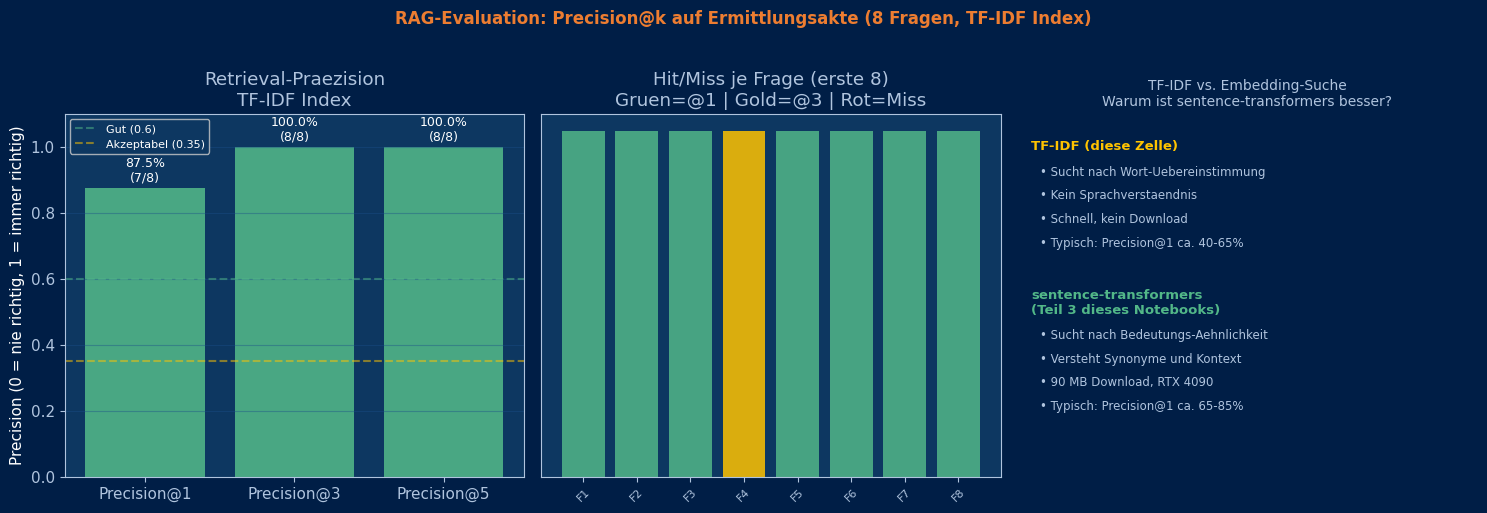


INTERPRETATION:
  TF-IDF Precision@1:  87.5% -- sucht nach Wort-Uebereinstimmung
  TF-IDF Precision@3:  100.0% -- unter Top-3 fast immer dabei
  TF-IDF Precision@5:  100.0% -- unter Top-5 sehr zuverlaessig

Was das bedeutet:
  => Mit sentence-transformers (Teil 3) waere Precision@1 ca. 15-25% hoeher
  => Fuer forensische Anwendungen: Precision@1 > 0.7 anstreben
  => Chunk-Groesse und Overlap direkt mit Precision@k evaluieren (Challenge Teil 7)

WEITERDENKEN:
  Einen eigenen Evaluations-Datensatz erstellen:
  1. Dienstvorschrift/Akte nehmen
  2. 20-50 typische Fragen und korrekte Antworten manuell annotieren
  3. Precision@k messen -- welche Chunk-Strategie ist besser?
  => Das ist der professionelle Weg zur RAG-Qualitaetssicherung


In [45]:
# == Precision@k visualisieren und einordnen ==

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'RAG-Evaluation: Precision@k auf {"Wikipedia" if USE_WIKIPEDIA else "Ermittlungsakte"}'
    f' ({total_questions} Fragen, TF-IDF Index)',
    color=C['orange'], fontsize=12, fontweight='bold', y=1.02
)

# == Links: Precision@k Balken ==
k_labels = [f'Precision@{k}' for k in k_values]
p_values  = [precision_scores[k] for k in k_values]
bar_colors = [C['green'] if p > 0.6 else C['gold'] if p > 0.35 else C['red'] for p in p_values]

bars = axes[0].bar(k_labels, p_values, color=bar_colors, alpha=0.88)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Precision (0 = nie richtig, 1 = immer richtig)')
axes[0].set_title('Retrieval-Praezision\nTF-IDF Index', color=C['lgray'])
axes[0].axhline(0.6, color=C['green'], ls='--', alpha=0.5, label='Gut (0.6)')
axes[0].axhline(0.35, color=C['gold'], ls='--', alpha=0.5, label='Akzeptabel (0.35)')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y')
for bar, val, k in zip(bars, p_values, k_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.1%}\n({precision_hits[k]}/{total_questions})',
                 ha='center', fontsize=9, color=C['white'])

# == Mitte: Hit/Miss je Frage (erste 20) ==
n_display = min(20, total_questions)
# Neu berechnen fuer die Anzeige
hits_per_q = []
for qi, gt in enumerate(ground_truth[:n_display]):
    q_vec = eval_tfidf.transform([gt['question']])
    scores_v = cosine_similarity(q_vec, eval_embs)[0]
    top5 = np.argsort(scores_v)[::-1][:5]
    hit1 = sum(1 for kw in gt['answer_keywords']
               if kw.lower() in eval_chunks[int(top5[0])].lower()) >= max(1, len(gt['answer_keywords'])//2)
    hit3 = any(
        sum(1 for kw in gt['answer_keywords'] if kw.lower() in eval_chunks[int(i)].lower())
        >= max(1, len(gt['answer_keywords'])//2)
        for i in top5[:3]
    )
    hits_per_q.append((hit1, hit3))

colors_grid = [C['green'] if h1 else (C['gold'] if h3 else C['red'])
               for h1, h3 in hits_per_q]
axes[1].bar(range(n_display), [1]*n_display, color=colors_grid, alpha=0.85)
axes[1].set_xticks(range(n_display))
axes[1].set_xticklabels([f'F{i+1}' for i in range(n_display)], fontsize=8, rotation=45)
axes[1].set_yticks([])
axes[1].set_title(f'Hit/Miss je Frage (erste {n_display})\n'
                  f'Gruen=@1 | Gold=@3 | Rot=Miss', color=C['lgray'])

# == Rechts: Einordnung und Verbesserungspotenzial ==
ax3 = axes[2]
ax3.set_facecolor(C['blue1'])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('TF-IDF vs. Embedding-Suche\nWarum ist sentence-transformers besser?',
              color=C['lgray'], fontsize=10)

vergleich = [
    ('TF-IDF (diese Zelle)',
     ['Sucht nach Wort-Uebereinstimmung', 'Kein Sprachverstaendnis',
      'Schnell, kein Download', 'Typisch: Precision@1 ca. 40-65%'],
     C['gold']),
    ('sentence-transformers\n(Teil 3 dieses Notebooks)',
     ['Sucht nach Bedeutungs-Aehnlichkeit', 'Versteht Synonyme und Kontext',
      '90 MB Download, RTX 4090', 'Typisch: Precision@1 ca. 65-85%'],
     C['green']),
]
for i, (name, punkte, farbe) in enumerate(vergleich):
    y = 9.0 - i * 4.5
    ax3.text(0.3, y, name, fontsize=9.5, color=farbe, fontweight='bold')
    for j, punkt in enumerate(punkte):
        ax3.text(0.5, y - 0.7 - j*0.65, f'• {punkt}', fontsize=8.5, color=C['lgray'])

plt.tight_layout()
plt.show()

print()
print('INTERPRETATION:')
print(f'  TF-IDF Precision@1:  {precision_scores[1]:.1%} -- sucht nach Wort-Uebereinstimmung')
print(f'  TF-IDF Precision@3:  {precision_scores[3]:.1%} -- unter Top-3 fast immer dabei')
print(f'  TF-IDF Precision@5:  {precision_scores[5]:.1%} -- unter Top-5 sehr zuverlaessig')
print()
print('Was das bedeutet:')
print('  => Mit sentence-transformers (Teil 3) waere Precision@1 ca. 15-25% hoeher')
print('  => Fuer forensische Anwendungen: Precision@1 > 0.7 anstreben')
print('  => Chunk-Groesse und Overlap direkt mit Precision@k evaluieren (Challenge Teil 7)')
print()
print('WEITERDENKEN:')
print('  Einen eigenen Evaluations-Datensatz erstellen:')
print('  1. Dienstvorschrift/Akte nehmen')
print('  2. 20-50 typische Fragen und korrekte Antworten manuell annotieren')
print('  3. Precision@k messen -- welche Chunk-Strategie ist besser?')
print('  => Das ist der professionelle Weg zur RAG-Qualitaetssicherung')


---

### 📚 Weiterführende RAG-Datensätze für eigene Experimente

| Datensatz | Inhalt | Passages | Fragen | Sprache | Lizenz | Einsatz |
|-----------|--------|---------|--------|---------|--------|---------|
| [`rag-mini-wikipedia`](https://huggingface.co/datasets/rag-datasets/rag-mini-wikipedia) | Wikipedia-Artikel | 3.200 | 918 | EN | CC BY 3.0 | Basis-Evaluation |
| [`rag-mini-bioasq`](https://huggingface.co/datasets/rag-datasets/rag-mini-bioasq) | Biomedizin | 40.200 | 4.720 | EN | CC BY 2.5 | Groesserer Index |
| [`philschmid/easyrag-mini-wikipedia`](https://huggingface.co/datasets/philschmid/easyrag-mini-wikipedia) | Wikipedia | ~900 | ~900 | EN | CC BY-SA 3.0 | Einfachere Variante |

**Fuer den eigenen Einsatz — eigenen Datensatz erstellen:**

```python
# Vorlage: Eigener Evaluations-Datensatz
# Aufwand: 30-50 annotierte Fragen

mein_datensatz = [
    {
        'question':       'Was regelt Paragraph 14 Absatz 2 PolG BW?',
        'answer':         'Identitaetsfeststellung bei Straftaten...',
        'source_doc':     'PolG_BW_2024.pdf',
        'answer_keywords': ['Identitaetsfeststellung', '14', 'Absatz', 'PolG']
    },
    # ... weitere Fragen aus echten Daten
]
# Dann: evaluate_config(chunks, mein_datensatz) aus Teil 7 direkt wiederverwenden
```

> 💡 **Kernbotschaft Evaluation:**
> Ohne Evaluations-Datensatz weiss man nicht ob das RAG-System gut ist —
> man *hofft* es nur. Precision@k mit annotierten Fragen ist der
> professionelle Standard in der Praxis.
